# Eval Analysis — Per-Env-Type Results

Analyse output from `eval_ftr.py` / `eval_d3qn.py` / `eval_ftr_rand.py` etc. with `--output_dir`.

Each eval run writes into its output directory:
- **eval_summary.csv** — one row per repeat, overall aggregate metrics
- **eval_per_env.csv** — one row per (repeat × env_type), per-terrain-row metrics
- **eval_per_spot.csv** — one row per (repeat × env_type × depth_col), per-spawn-spot metrics
- **eval_episodes.csv** — one row per completed episode, granular data
- **eval_terrain.json** — which terrain each `eval_id` ran on, its env-type (row) names and
  depth-column count
- **terrain/** — a copy of that terrain's generator config (`gen_config/`), preview plot
  (`plot/<name>.svg` + a rasterised `.png`), birth points and map extent, taken from
  `src/FTR-Benchmark/ftr_envs/assets/terrain/`

Multiple runs (different policies / configs) can share the same output dir and are distinguished by `eval_id`.

In [17]:
import json
import re
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    "font.size":        15,
    "axes.titlesize":   18,
    "axes.labelsize":   15,
    "xtick.labelsize":  14,
    "ytick.labelsize":  15,
    "legend.fontsize":  15,
    "figure.titlesize": 18,
})

# Workspace root — notebook lives at <WS_ROOT>/notebooks/eval_analysis.ipynb
try:
    WS_ROOT = Path(__vsc_ipynb_file__).resolve().parent.parent
except NameError:
    WS_ROOT = Path.cwd().parent  # fallback when cwd is the notebooks/ dir

# ── CONFIG ────────────────────────────────────────────────────────────────────
# Paths relative to WS_ROOT (or absolute — both work).
EVAL_DIRS = [
    #"experiments/baselines/atd3qn/eval_mixed",
    #"experiments/baselines/icmd3qn/eval_mixed",
    #"experiments/baselines/creps/eval_creps",
    #"experiments/baselines/hfc/eval_new",
    #"experiments/baselines/mitriakov/eval_slick",
    "experiments/baselines/marv_rl_vel/eval_mixed",
    "experiments/baselines/marv_rl_vel/eval_new",
    #"experiments/baselines/mitriakov/eval_slick",
    "experiments/baselines/marv_rl_2/eval",
    "experiments/baselines/marv_rl_set_v/eval",


]

# Master terrain asset tree. Only consulted for terrains an eval dir didn't carry its own
# copy of (evals predating eval_terrain.json, or dirs synced without their terrain/ subdir).
TERRAIN_ASSETS_DIR = WS_ROOT / "src/FTR-Benchmark/ftr_envs/assets/terrain"

# Where rasterised / re-rendered terrain previews are cached (created on demand).
TERRAIN_PREVIEW_CACHE = WS_ROOT / "logs/terrain_previews"

# Human-readable labels for each eval_id (optional; falls back to eval_id string).
EVAL_LABELS: dict[str, str] = {
    "rand_best":            "Tuned baseline",
    "rand_range_synced":    "Random symmetric",
    "rand_range_unsynced":  "Random unsymmetric",
    "rand_straight":        "Forward only",
    "best_long":            "Ours",
    "best":                 "Trial 160",
    "avaraged_local":       "Averaged",
    "david":                "Spring-based",
    "legacy_architecture":  "Spring architecture",
    "optuna_51":"Trial 51",
    "optuna_112":"Trial 112",
    "optuna_225":"Trial 225",
    "optuna_230":"Trial 230",
}

# Colour palette for multi-eval comparison (auto-cycles if more evals than colours)
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

# Short, presentation-friendly env-type names (used for tick labels). Keys are the
# obstacle type names — for cur_mixed the hand-authored row names, for generated
# terrains the `rows[].type` values in the generator config.
ENV_NAME_SHORT: dict[str, str] = {
    # cur_mixed (legacy, hand-authored)
    "raised_platform":     "Raised plat.",
    "lowered_platform":    "Lowered plat.",
    "rails":               "Rails",
    "diag_rail":           "Diag. rail",
    "asymmetric_platform": "Asym. plat.",
    "diag_mound":          "Diag. mound",
    "trenches":            "Trenches",
    "cobblestone":         "Cobblestone",
    "steps_lowered":       "Steps down",
    "steps_raised":        "Steps up",
    "large_blocks":        "Lg. blocks",
    "medium_blocks":       "Md. blocks",
    "diag_blocks":         "Diag. blocks",
    "diag_platform":       "Diag. plat.",
    "large_steps":         "Lg. steps",
    "flat_patch":          "Flat",
    # ftr_terrain_gen obstacle types (custom_mixed, pan_symmetric, ...)
    "double_trench":         "Double trench",
    "widening_trench":       "Widening trench",
    "log_crossing":          "Log",
    "twin_rails":            "Twin rails",
    "diagonal_trunk":        "Diag. trunk",
    "raised_stairs":         "Stairs up",
    "lowered_stairs":        "Stairs down",
    "cobblestones":          "Cobbles",
    "rock_formation":        "Rocks",
    "diagonal_pyramid":      "Diag. pyramid",
    "half_platform":         "Half plat.",
    "stump":                 "Stump",
    "stairs_ascent_descent": "Stairs 1-way",
}

# A course may repeat an obstacle type in several rows at different settings; those rows
# are named <type>_2, <type>_3, ... and shorten to "<Short> 2", "<Short> 3".
_ROW_SUFFIX = re.compile(r"^(?P<base>.+?)_(?P<n>\d+)$")

def env_short(name: str) -> str:
    """Map a full env_type_name to its short, presentation-friendly label."""
    if name in ENV_NAME_SHORT:
        return ENV_NAME_SHORT[name]
    m = _ROW_SUFFIX.match(name)
    if m and m["base"] in ENV_NAME_SHORT:
        return f'{ENV_NAME_SHORT[m["base"]]} {m["n"]}'
    return name
# ─────────────────────────────────────────────────────────────────────────────

## 1  Load data

In [18]:
def _resolve(d: str | Path) -> Path:
    p = Path(d)
    return p if p.is_absolute() else WS_ROOT / p

def _load(name: str, required: bool = True) -> pd.DataFrame | None:
    frames = []
    for d in EVAL_DIRS:
        p = _resolve(d) / name
        if p.exists():
            df = pd.read_csv(p)
            df["eval_dir"] = str(_resolve(d))   # provenance: where to look for terrain assets
            frames.append(df)
        else:
            print(f"[warn] {p} not found — skipping")
    if not frames:
        if required:
            raise FileNotFoundError(f"No {name} found in {EVAL_DIRS}")
        return None
    df = pd.concat(frames, ignore_index=True)
    df["label"] = df["eval_id"].map(lambda eid: EVAL_LABELS.get(eid, eid))
    return df

summary_df  = _load("eval_summary.csv")
per_env_df  = _load("eval_per_env.csv")
episodes_df = _load("eval_episodes.csv")
per_spot_df = _load("eval_per_spot.csv", required=False)

eval_ids = summary_df["eval_id"].unique().tolist()

# Stable ordering (success rate descending) and per-label colors used by all plots.
_mean_sr   = summary_df.groupby("eval_id")["success_rate"].mean()
EVAL_ORDER = sorted(eval_ids, key=lambda eid: _mean_sr.get(eid, 0), reverse=True)
LABEL_COLOR = {EVAL_LABELS.get(eid, eid): PALETTE[i % len(PALETTE)]
               for i, eid in enumerate(EVAL_ORDER)}

[warn] /home/robot/workspaces/MARV_RL/experiments/baselines/marv_rl_vel/eval_new/eval_summary.csv not found — skipping
[warn] /home/robot/workspaces/MARV_RL/experiments/baselines/marv_rl_vel/eval_new/eval_per_env.csv not found — skipping
[warn] /home/robot/workspaces/MARV_RL/experiments/baselines/marv_rl_vel/eval_new/eval_episodes.csv not found — skipping
[warn] /home/robot/workspaces/MARV_RL/experiments/baselines/marv_rl_vel/eval_new/eval_per_spot.csv not found — skipping


## 2  Resolve terrains

Each eval's terrain comes from its `eval_terrain.json` manifest (written by the eval job),
falling back to the `terrain` column the CSVs already carry. The terrain then determines:

- **env-type names** — the ordered obstacle rows of the course (row 0 = lowest world Y)
- **number of env types / depth columns** — the course's row × repeat grid, straight out of
  the generator config, so a regenerated terrain needs no edits here
- **the preview image** used beside the per-spot heatmaps

Evals are grouped by terrain, and every later section iterates those groups.

In [19]:
# ── Terrain manifests written by the eval jobs ───────────────────────────────
def _load_manifests() -> tuple[dict, dict]:
    """Merge every EVAL_DIRS/eval_terrain.json into {eval_id: entry}, {terrain: entry}."""
    evals, terrains = {}, {}
    for d in EVAL_DIRS:
        root = _resolve(d)
        p = root / "eval_terrain.json"
        if not p.exists():
            continue
        try:
            m = json.loads(p.read_text())
        except (OSError, ValueError) as e:
            print(f"[warn] unreadable {p}: {e}")
            continue
        for eid, entry in (m.get("evals") or {}).items():
            evals[eid] = {**entry, "eval_dir": root}
        for name, entry in (m.get("terrains") or {}).items():
            terrains.setdefault(name, {**entry, "eval_dir": root})
    return evals, terrains

MANIFEST_EVALS, MANIFEST_TERRAINS = _load_manifests()

# ── Terrain asset lookup: the eval's own copy first, then the master asset tree ──
def _find_asset(terrain: str, sub: str, ext: str) -> Path | None:
    cands = []
    entry = MANIFEST_TERRAINS.get(terrain)
    if entry is not None:
        cands.append(Path(entry["eval_dir"]) / "terrain" / sub / f"{terrain}{ext}")
    cands += [_resolve(d) / "terrain" / sub / f"{terrain}{ext}" for d in EVAL_DIRS]
    cands.append(TERRAIN_ASSETS_DIR / sub / f"{terrain}{ext}")
    return next((c for c in cands if c.is_file()), None)

def _gen_config(terrain: str) -> dict | None:
    """The ftr_terrain_gen config the terrain was generated from (None if hand-authored)."""
    p = _find_asset(terrain, "gen_config", ".yaml")
    if p is None:
        return None
    try:
        cfg = yaml.safe_load(p.read_text())
    except (OSError, ValueError):
        return None
    return cfg if isinstance(cfg, dict) and cfg.get("rows") else None

def _unique_row_names(types: list[str]) -> list[str]:
    """Same disambiguation the eval side uses: 2nd `cobblestones` row -> cobblestones_2."""
    counts, names = {}, []
    for t in types:
        counts[t] = counts.get(t, 0) + 1
        names.append(t if counts[t] == 1 else f"{t}_{counts[t]}")
    return names

# ── Terrain preview image ────────────────────────────────────────────────────
def _usable_raster(p: Path) -> bool:
    """True if *p* is an image with actual content.

    ImageMagick's `convert` (and other rasterisers) exit 0 having written a uniformly
    blank PNG when no SVG delegate is installed. Trusting the exit code yields a preview
    that imshow renders as one flat colour, so check the pixels instead.
    """
    if not p.is_file():
        return False
    try:
        img = mpimg.imread(str(p))
    except Exception:
        return False
    if img.ndim == 3 and img.shape[2] == 4:
        img = img[..., :3]          # a uniform alpha channel is normal; ignore it
    return float(np.nanmax(img) - np.nanmin(img)) > 1e-3

def _rasterize_svg(svg: Path, dest: Path) -> bool:
    """SVG -> PNG, since matplotlib can only imread raster images."""
    dest.parent.mkdir(parents=True, exist_ok=True)
    try:
        import cairosvg
        cairosvg.svg2png(url=str(svg), write_to=str(dest), output_width=1600)
        if _usable_raster(dest):
            return True
    except Exception:
        pass
    import shutil as _sh, subprocess
    # `convert` last: its SVG support depends on a delegate that is often absent.
    for cmd in (["rsvg-convert", "-w", "1600", "-o", str(dest), str(svg)],
                ["inkscape", str(svg), "--export-type=png", "-w", "1600", f"--export-filename={dest}"],
                ["convert", "-density", "150", str(svg), str(dest)]):
        if _sh.which(cmd[0]) is None:
            continue
        try:
            subprocess.run(cmd, check=True, capture_output=True)
        except subprocess.CalledProcessError:
            continue
        if _usable_raster(dest):
            return True
    dest.unlink(missing_ok=True)
    return False

def _render_from_map(terrain: str, dest: Path) -> bool:
    """Last resort: redraw the preview from the raw heightmap (mirrors
    ftr_terrain_gen.assembler.build_plot / terrain_assets._render_preview_png)."""
    map_p, cfg_p = _find_asset(terrain, "map", ".map"), _find_asset(terrain, "config", ".yaml")
    if map_p is None or cfg_p is None:
        return False
    try:
        with open(map_p, "rb") as f:
            hmap = np.load(f, allow_pickle=True)
        map_cfg = (yaml.safe_load(cfg_p.read_text()) or {}).get("map", {})
        cell = float(map_cfg.get("cell_size", 0.05))
        gen = _gen_config(terrain)
        if gen is not None:
            tile = gen.get("tile", {}) or {}
            border = float(gen.get("border_width", 2.0))
            b = round(border / cell)
            if b > 0:
                hmap = hmap[b:-b, b:-b]
            half_x = gen["repeats"] * float(tile.get("width", 5.0)) / 2
            half_y = len(gen["rows"]) * float(tile.get("depth", 10 / 3)) / 2
            extent = (-half_x, half_x, -half_y, half_y)
        else:
            # No generator config to say how wide the sentinel border ring is, so blank the
            # sentinel cells instead — left in, their huge drop below the real terrain
            # stretches the colormap until the actual steps wash out to one shade.
            lo, up = list(map_cfg["lower"])[:2], list(map_cfg["upper"])[:2]
            extent = (lo[0], up[0], lo[1], up[1])
            v0 = float(hmap.min())
            rest = hmap[hmap > v0 + 1e-6]
            if rest.size and float(rest.min()) - v0 >= 0.25 * max(float(rest.max() - rest.min()), 1e-6):
                hmap = np.where(hmap <= v0 + 1e-6, np.nan, hmap)

        w_m, d_m = extent[1] - extent[0], extent[3] - extent[2]
        fig = plt.figure(figsize=(12, max(12 * d_m / w_m, 1.0)), dpi=100)
        ax = fig.add_axes((0, 0, 1, 1))
        ax.imshow(hmap.T, origin="lower", cmap="terrain", interpolation="nearest", extent=extent)
        if gen is not None:
            tile = gen.get("tile", {}) or {}
            for k in range(gen["repeats"] + 1):
                ax.axvline(extent[0] + k * float(tile.get("width", 5.0)), color="black", linewidth=1.5)
            for r in range(len(gen["rows"]) + 1):
                ax.axhline(extent[2] + r * float(tile.get("depth", 10 / 3)), color="black", linewidth=1.5)
        birth_p = _find_asset(terrain, "birth", ".json")
        if birth_p is not None:
            birth = json.loads(birth_p.read_text())
            st = np.array([e["start_point"][:2] for e in birth])
            tg = np.array([e["target_point"][:2] for e in birth])
            ax.scatter(st[:, 0], st[:, 1], marker="o", color="lime", edgecolors="black", s=40, zorder=5)
            ax.scatter(tg[:, 0], tg[:, 1], marker="*", color="red", edgecolors="black", s=90, zorder=5)
        ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3]); ax.axis("off")
        dest.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(dest, format="png", bbox_inches="tight", pad_inches=0)
        plt.close(fig)
        return True
    except Exception as e:
        print(f"[warn] could not render {terrain} preview from map: {e}")
        return False

def _terrain_preview(terrain: str) -> Path | None:
    """PNG of the terrain's heightmap plot — the eval's own copy if it has one.

    Falls back to rasterising the shipped SVG, then to redrawing from the raw heightmap.
    Every candidate is content-checked, so a blank file from a broken rasteriser (or one
    cached by an earlier run) is discarded rather than plotted as a flat rectangle.
    """
    png = _find_asset(terrain, "plot", ".png")
    if png is not None and _usable_raster(png):
        return png
    cached = TERRAIN_PREVIEW_CACHE / f"{terrain}.png"
    if _usable_raster(cached):
        return cached
    svg = _find_asset(terrain, "plot", ".svg")
    if svg is not None and _rasterize_svg(svg, cached):
        return cached
    if _render_from_map(terrain, cached) and _usable_raster(cached):
        return cached
    return None

# ── Per-terrain layout ───────────────────────────────────────────────────────
# How a terrain's preview image must be transformed so its lanes/columns land in the same
# corner as the heatmaps' (row 0 bottom-left, difficulty rising rightwards).
# Courses built by ftr_terrain_gen already agree — CourseGrid puts row 0 at the lowest
# world Y and col 0 at the lowest world X. cur_mixed indexes BOTH axes in descending world
# order (env type 0 at Y≈23.3 down to Y≈-21.5, depth col 0 at X≈19.3 down to X≈-23), so its
# preview needs flipping on both — i.e. a plain 180° rotation, not a mirror.
_PREVIEW_FLIP: dict[str, tuple[bool, bool]] = {"cur_mixed": (True, True)}

@dataclass
class TerrainInfo:
    name: str
    env_names: list[str]     # index = env_type_idx, row 0 = lowest world Y
    num_depth_cols: int      # difficulty columns, col 0 = easiest
    preview: Path | None
    sep_row: int | None      # dashed separator below this row (cur_mixed's detached flat patch)
    preview_flip: tuple[bool, bool] = (False, False)   # (flip rows, flip cols)

    @property
    def num_env_types(self) -> int:
        return len(self.env_names)

    @property
    def short_names(self) -> list[str]:
        return [env_short(n) for n in self.env_names]

    def name_of(self, idx: int) -> str:
        return self.env_names[idx] if 0 <= idx < self.num_env_types else f"env_{idx:02d}"

    def short_of(self, idx: int) -> str:
        return env_short(self.name_of(idx))

def _terrain_info(terrain: str) -> TerrainInfo:
    entry = MANIFEST_EVALS_BY_TERRAIN.get(terrain, {})
    gen = _gen_config(terrain)

    # env-type names: what the eval recorded > the generator config > the CSVs > generic
    names = list(entry.get("env_type_names") or [])
    if not names and gen is not None:
        names = _unique_row_names([r["type"] for r in gen["rows"]])
    if not names:
        sub = per_env_df[per_env_df["terrain"] == terrain]
        m = sub.drop_duplicates("env_type_idx").set_index("env_type_idx")["env_type_name"].to_dict()
        n = (max(m) + 1) if m else 0
        names = [m.get(i, f"env_{i:02d}") for i in range(n)]

    cols = entry.get("num_depth_cols") or (gen or {}).get("repeats")
    if not cols and per_spot_df is not None:
        sub = per_spot_df[per_spot_df["terrain"] == terrain]
        cols = int(sub["depth_col"].max()) + 1 if len(sub) else None
    cols = int(cols or 10)

    # cur_mixed's flat patch is a separate USD placed off the end of the course, not a
    # course row — set it off from the graded rows with a dashed line.
    sep = len(names) - 1 if terrain == "cur_mixed" and names and names[-1] == "flat_patch" else None

    return TerrainInfo(terrain, names, cols, _terrain_preview(terrain), sep,
                       _PREVIEW_FLIP.get(terrain, (False, False)))

def terrain_preview_image(ti: TerrainInfo):
    """The terrain preview, oriented to match the heatmaps (env type 0 bottom, col 0 left)."""
    img = mpimg.imread(str(ti.preview))
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)   # greyscale raster — show as-is, not colormapped
    flip_rows, flip_cols = ti.preview_flip
    if flip_rows:
        img = img[::-1]
    if flip_cols:
        img = img[:, ::-1]
    return img

# ── eval_id -> terrain, and the terrain groups every section iterates ────────
_csv_terrain = summary_df.drop_duplicates("eval_id").set_index("eval_id")["terrain"].to_dict()
TERRAIN_OF = {
    eid: (MANIFEST_EVALS.get(eid, {}).get("terrain") or _csv_terrain.get(eid) or "unknown")
    for eid in eval_ids
}
MANIFEST_EVALS_BY_TERRAIN = {}
for _eid, _e in MANIFEST_EVALS.items():
    if _e.get("terrain"):
        MANIFEST_EVALS_BY_TERRAIN.setdefault(_e["terrain"], _e)

TERRAIN_GROUPS: dict[str, list[str]] = {}
for eid in EVAL_ORDER:
    TERRAIN_GROUPS.setdefault(TERRAIN_OF[eid], []).append(eid)
TERRAINS = {t: _terrain_info(t) for t in TERRAIN_GROUPS}

def terrain_groups(df: pd.DataFrame | None = None):
    """Yield (TerrainInfo, [eval_ids]) per terrain, restricted to eval_ids present in *df*."""
    for t, eids in TERRAIN_GROUPS.items():
        if df is not None:
            present = set(df["eval_id"].unique())
            eids = [e for e in eids if e in present]
        if eids:
            yield TERRAINS[t], eids

def label_of(eid: str) -> str:
    return EVAL_LABELS.get(eid, eid)

def fig_title(ti: TerrainInfo, text: str) -> str:
    """Title that names the terrain, so figures stay unambiguous once split by terrain."""
    return f"{text}  —  {ti.name}" if len(TERRAIN_GROUPS) > 1 else text

# ── Report ───────────────────────────────────────────────────────────────────
print(f"Loaded {len(eval_ids)} eval run(s) across {len(TERRAIN_GROUPS)} terrain(s):\n")
for ti, eids in terrain_groups():
    src = "manifest" if ti.name in MANIFEST_EVALS_BY_TERRAIN else "CSV terrain column"
    print(f"  terrain '{ti.name}'  ({src}) — {ti.num_env_types} env types x {ti.num_depth_cols} depth cols")
    print(f"    rows: {', '.join(ti.short_names)}")
    print(f"    preview: {ti.preview if ti.preview else '(none found)'}")
    for eid in eids:
        n_rep = summary_df[summary_df.eval_id == eid].shape[0]
        n_eps = episodes_df[episodes_df.eval_id == eid].shape[0]
        print(f"    - {label_of(eid)}  ({eid}) — {n_rep} repeat(s), {n_eps} episodes")
    print()

if len(TERRAIN_GROUPS) > 1:
    print("[!] These evals ran on different terrains — env-type index N means a different\n"
          "    obstacle in each. Every section below draws one figure per terrain and only\n"
          "    compares evals within a terrain.")
if per_spot_df is None:
    print("[warn] no eval_per_spot.csv — per-spot sections will be skipped.")

# ── Stale-binning check ──────────────────────────────────────────────────────
# The CSVs record the env_type_name the eval assigned to each index. If that disagrees
# with the terrain's current rows, the eval binned target positions with a *different*
# layout than the one being plotted — so env_type_idx / depth_col point at the wrong
# obstacles, and gaps appear where the old geometry could not reach. Relabelling can't
# repair that; the eval has to be re-run.
for ti, eids in terrain_groups(per_env_df):
    for eid in eids:
        sub = per_env_df[per_env_df.eval_id == eid]
        recorded = sub.drop_duplicates("env_type_idx").set_index("env_type_idx")["env_type_name"]
        mismatch = {i: n for i, n in recorded.items()
                    if i < ti.num_env_types and n != ti.env_names[i] and not str(n).startswith("env_")}
        if not mismatch:
            continue
        i0 = min(mismatch)
        print(f"\n[!] {label_of(eid)} ({eid}) was evaluated with a DIFFERENT layout than "
              f"'{ti.name}' currently has.\n"
              f"    e.g. env_type_idx {i0}: the CSV says '{mismatch[i0]}', the terrain says "
              f"'{ti.env_names[i0]}' ({len(mismatch)} of {len(recorded)} indices disagree).\n"
              f"    Its env_type_idx/depth_col were computed from other geometry, so rows and\n"
              f"    columns below are misattributed (and some will be empty). Re-run this eval.")

Loaded 3 eval run(s) across 1 terrain(s):

  terrain 'custom_mixed'  (manifest) — 17 env types x 10 depth cols
    rows: Raised plat., Double trench, Widening trench, Log, Twin rails, Diag. trunk, Stairs up, Stairs down, Stairs up 2, Cobbles, Cobbles 2, Rocks, Diag. pyramid, Half plat., Flat, Stump, Stairs 1-way
    preview: /home/robot/workspaces/MARV_RL/experiments/baselines/marv_rl_vel/eval_mixed/terrain/plot/custom_mixed.png
    - marv_rl  (marv_rl) — 15 repeat(s), 10067 episodes
    - marv_rl_set_vel  (marv_rl_set_vel) — 15 repeat(s), 8041 episodes
    - MARV_RL_velocity  (MARV_RL_velocity) — 10 repeat(s), 5343 episodes



## 3  Terrain overview

The course each group of evals ran on, taken from the terrain's own preview plot
(`ftr_envs/assets/terrain/plot/<name>.svg`, copied into the eval dir as a `.png`).

Previews are oriented to match every heatmap below: **env type 0 at the bottom**,
difficulty grading **left → right** across the depth columns. Terrains whose env-type /
depth-column indices run the other way round in world coordinates (`cur_mixed`) get their
preview rotated 180° — a rigid rotation, never a mirror, so diagonal obstacles keep leaning
the way they actually do.

Green circles are spawn points, red stars goals.

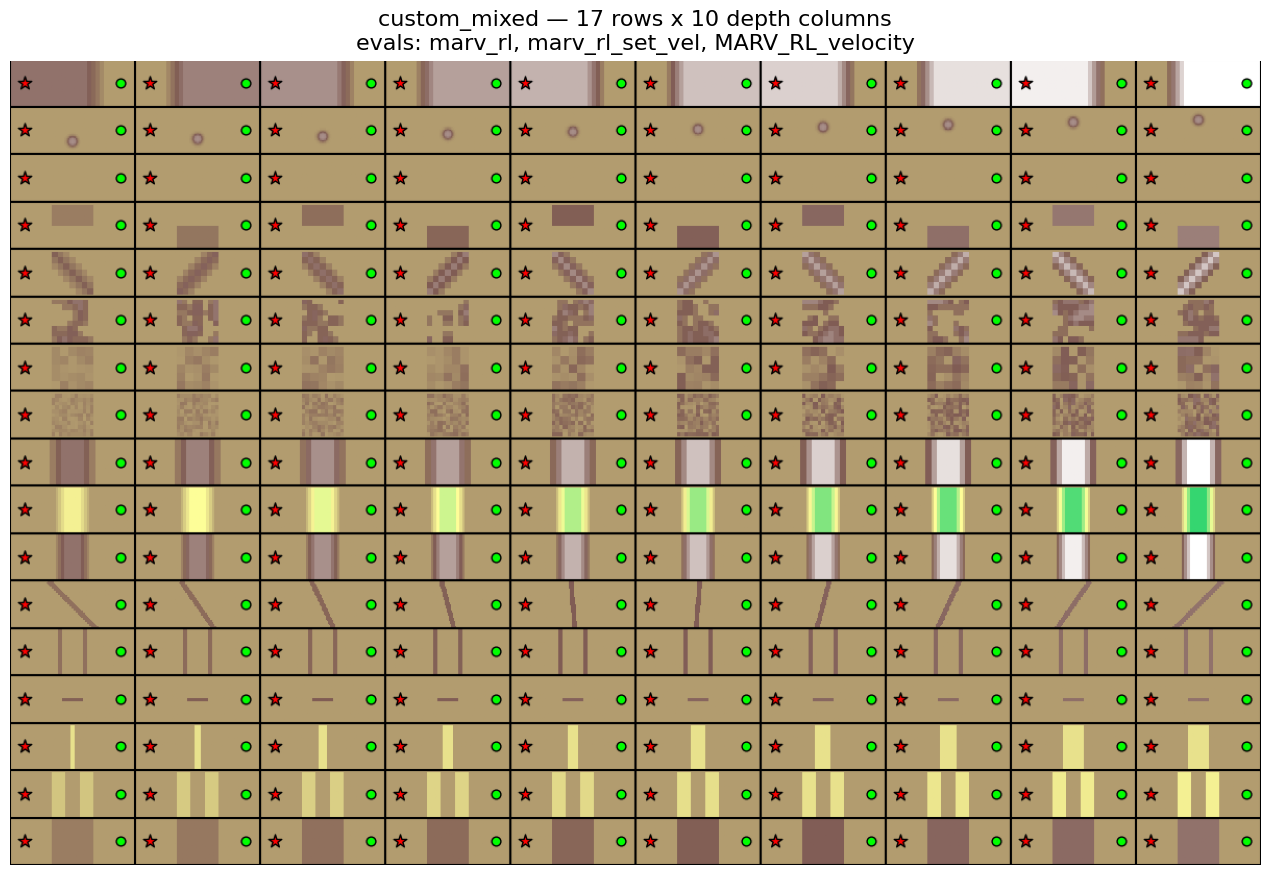

In [20]:
for ti, eids in terrain_groups():
    if ti.preview is None:
        print(f"[warn] no preview available for terrain '{ti.name}' — "
              f"looked in the eval dirs' terrain/plot/ and {TERRAIN_ASSETS_DIR}")
        continue
    img = terrain_preview_image(ti)
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(14, max(14 * h / w, 2.0)))
    ax.imshow(img)
    ax.axis("off")
    note = "  (rotated 180° to match the heatmaps below)" if all(ti.preview_flip) else ""
    ax.set_title(f"{ti.name} — {ti.num_env_types} rows x {ti.num_depth_cols} depth columns{note}\n"
                 f"evals: {', '.join(label_of(e) for e in eids)}", fontsize=16, pad=8)
    plt.tight_layout()
    plt.show()

## 4  Overall metrics (aggregate across all env types)

=== custom_mixed ===


,success_rate,failure_rate,explosion_rate,mean_step_reward,truncated_rate
label,,,,,
marv_rl,0.7932,0.1084,0.0,-0.0029,0.0981
marv_rl_set_vel,0.7054,0.0736,0.0,-0.0076,0.2209
MARV_RL_velocity,0.6419,0.0838,0.0,-0.0013,0.2744


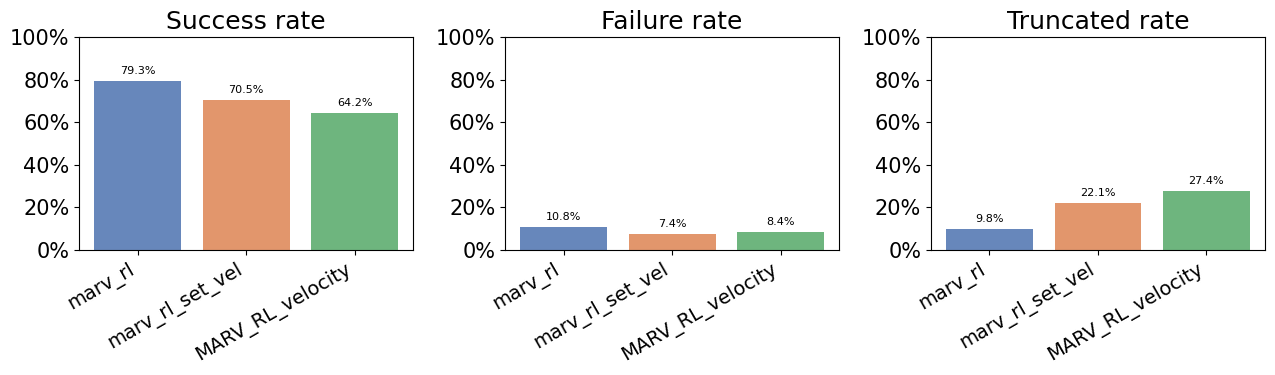

In [21]:
for ti, eids in terrain_groups(summary_df):
    labels = [label_of(e) for e in eids]
    s_sub = summary_df[summary_df.eval_id.isin(eids)]
    e_sub = episodes_df[episodes_df.eval_id.isin(eids)]

    agg = s_sub.groupby("label")[["success_rate","failure_rate","explosion_rate","mean_step_reward"]].mean()
    # Truncated rate is only derivable from episode-level data (not in summary CSV)
    trunc_rate = (
        e_sub.groupby("label")
        .apply(lambda g: (g["outcome"] == "truncated").mean())
        .rename("truncated_rate")
    )
    agg = agg.join(trunc_rate).reindex([l for l in labels if l in agg.index])
    print(f"=== {ti.name} ===")
    display(agg.round(4))

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, col, title in zip(axes,
        ["success_rate", "failure_rate", "truncated_rate"],
        ["Success rate", "Failure rate", "Truncated rate"]):
        vals = [agg.loc[lbl, col] for lbl in agg.index]
        colors = [LABEL_COLOR[lbl] for lbl in agg.index]
        errs = []
        for lbl in agg.index:
            if col == "truncated_rate":
                per_rep = (
                    e_sub[e_sub.label == lbl]
                    .groupby("repeat")
                    .apply(lambda g: (g["outcome"] == "truncated").mean())
                    .values
                )
                errs.append(per_rep.std() / np.sqrt(len(per_rep)) if len(per_rep) > 1 else 0)
            else:
                v = s_sub[s_sub.label == lbl][col].values
                errs.append(v.std() / np.sqrt(len(v)) if len(v) > 1 else 0)
        bars = ax.bar(agg.index, vals, capsize=5, color=colors, alpha=0.85)
        for bar, val, err in zip(bars, vals, errs):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + err + 0.02,
                    f"{val:.1%}", ha="center", va="bottom", fontsize=8)
        ax.set_title(title, fontsize=18)
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.tick_params(axis="x", rotation=30)
        for label in ax.get_xticklabels():
            label.set_ha("right")
    if len(TERRAIN_GROUPS) > 1:
        fig.suptitle(f"Terrain: {ti.name}", fontsize=18, y=1.03)
    plt.tight_layout()
    plt.show()

## 5  Per-env-type success / failure  (with 95 % CI from bootstrapped repeats)

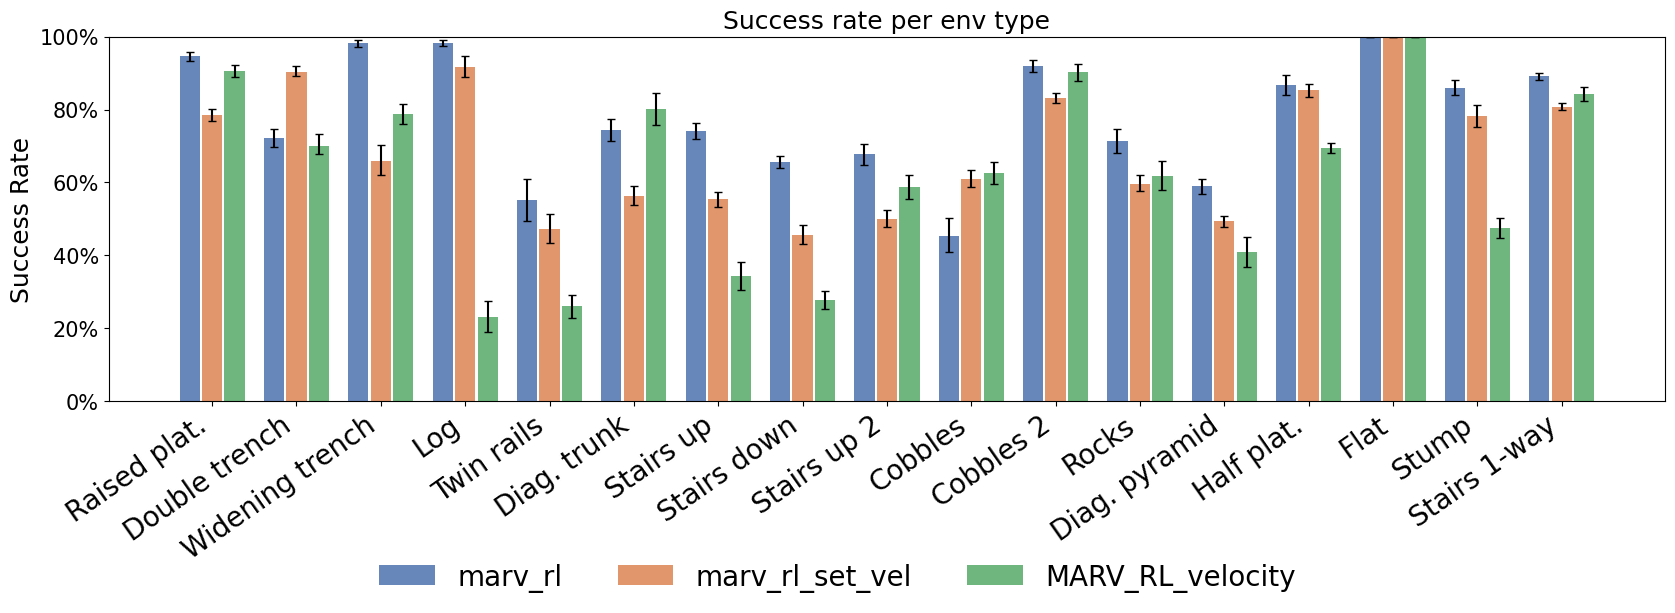

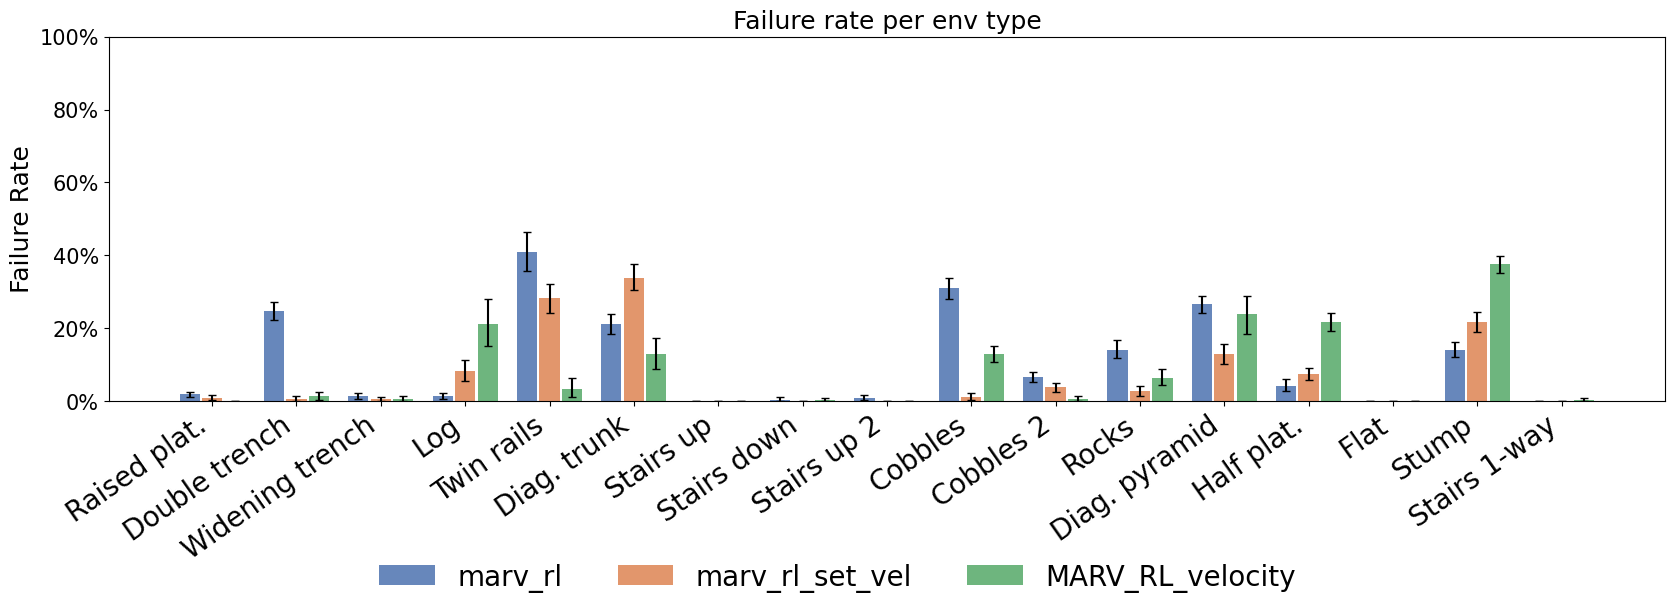

In [22]:
def bootstrap_ci(values: np.ndarray, n_boot: int = 2000, alpha: float = 0.05) -> tuple[float, float]:
    """Return (lo, hi) bootstrap confidence interval for the mean."""
    if len(values) < 2:
        return (0.0, 0.0)
    boots = np.random.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    return float(np.percentile(boots, 100*alpha/2)), float(np.percentile(boots, 100*(1-alpha/2)))

for ti, eids in terrain_groups(per_env_df):
    sub_all = per_env_df[per_env_df.eval_id.isin(eids)]
    env_order = sorted(sub_all["env_type_idx"].unique())
    x = np.arange(len(env_order))
    n_evals = len(eids)
    width = 0.8 / max(n_evals, 1)

    for metric, title in [("success_rate", "Success rate per env type"),
                          ("failure_rate", "Failure rate per env type")]:
        fig, ax = plt.subplots(figsize=(max(12, len(env_order)), 6))
        handles, labels_legend = [], []
        for ei, eid in enumerate(eids):
            lbl = label_of(eid)
            sub = sub_all[sub_all.eval_id == eid]
            means, lo_errs, hi_errs = [], [], []
            for idx in env_order:
                vals = sub[sub.env_type_idx == idx][metric].dropna().values
                if len(vals) == 0:
                    means.append(np.nan); lo_errs.append(0); hi_errs.append(0)
                else:
                    m = vals.mean()
                    lo, hi = bootstrap_ci(vals)
                    means.append(m); lo_errs.append(m - lo); hi_errs.append(hi - m)
            offset = (ei - n_evals / 2 + 0.5) * width
            bars = ax.bar(x + offset, means, width=width * 0.9,
                   yerr=[lo_errs, hi_errs], capsize=3,
                   color=LABEL_COLOR[lbl], alpha=0.85, label=lbl)
            handles.append(bars)
            labels_legend.append(lbl)

        ax.set_title(fig_title(ti, title))
        ax.set_xticks(x)
        ax.set_xticklabels([ti.short_of(i) for i in env_order], rotation=35, ha="right", fontsize=20)
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.set_ylabel(metric.replace("_", " ").title(), fontsize=18)
        fig.legend(handles, labels_legend, loc="lower center",
                   ncol=n_evals, bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=20)
        plt.tight_layout()
        #plt.savefig(fname=f"images/{ti.name}_{metric}_perenv.svg",format="svg",bbox_inches="tight")
        plt.show()

## 6  Per-env-type reward (box plots from episode data)

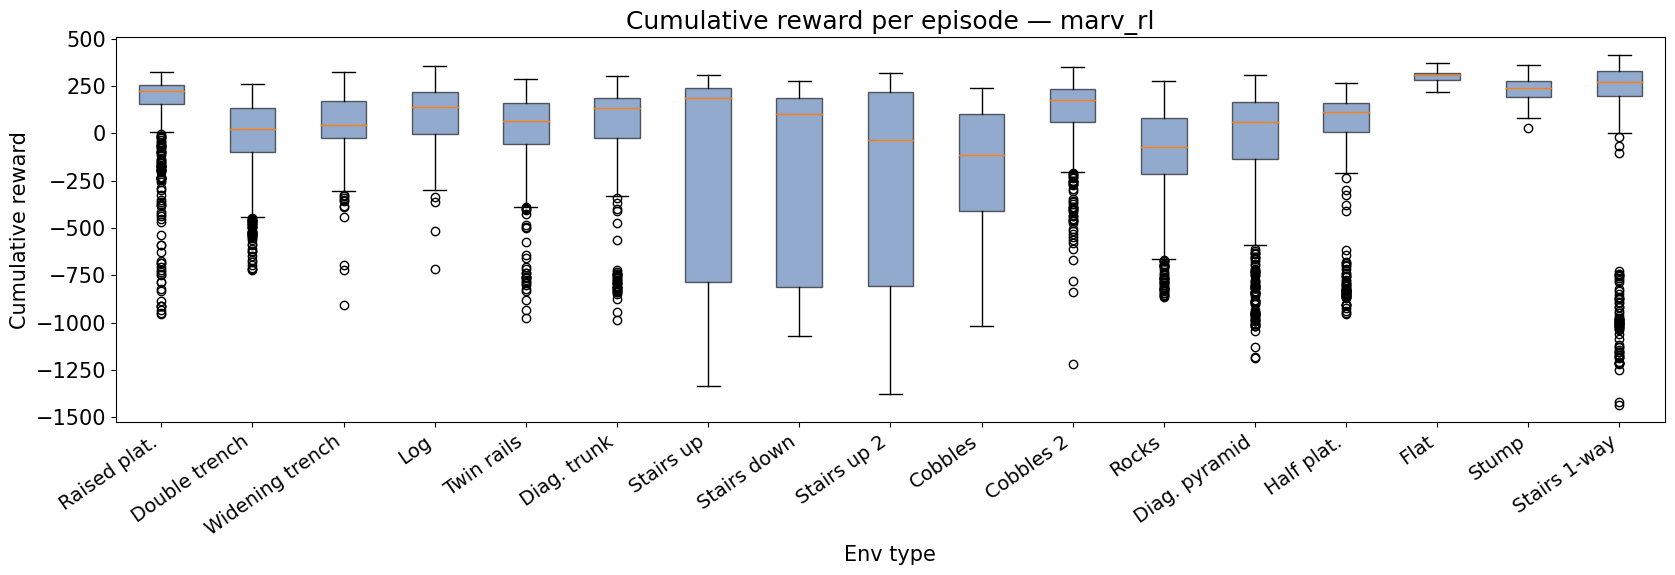

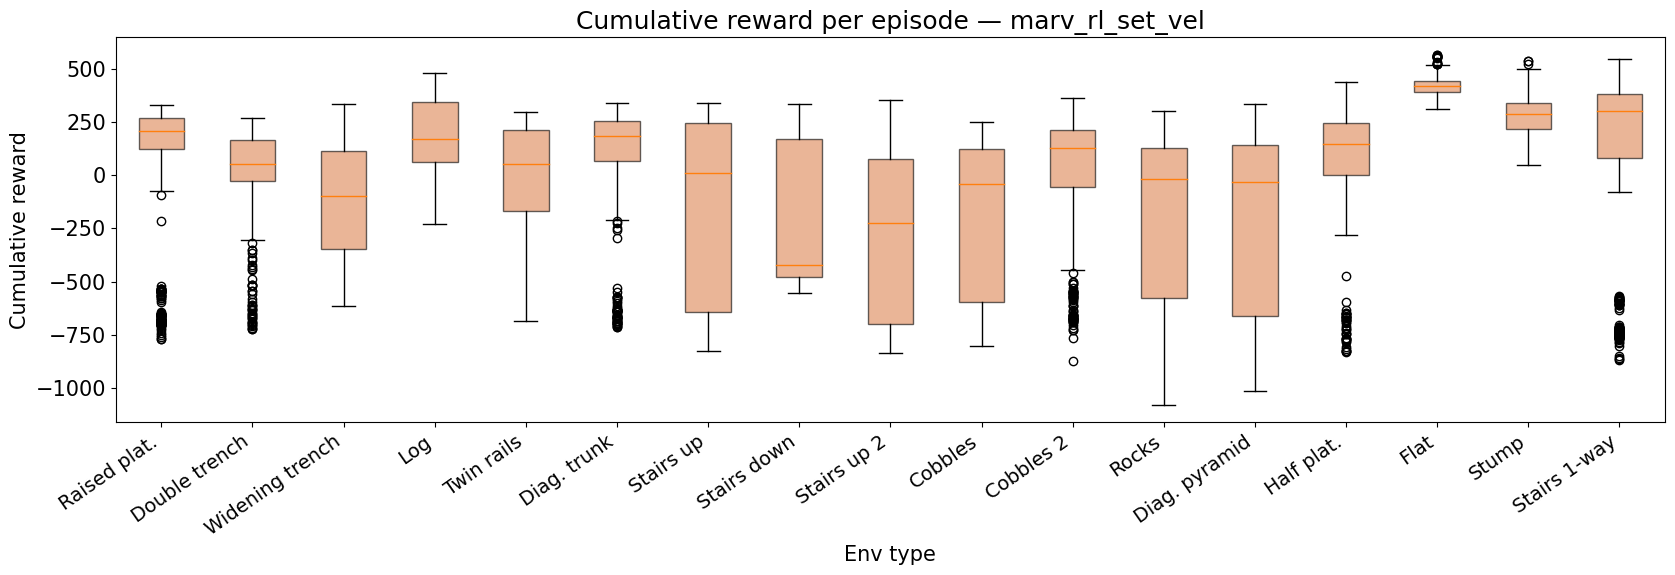

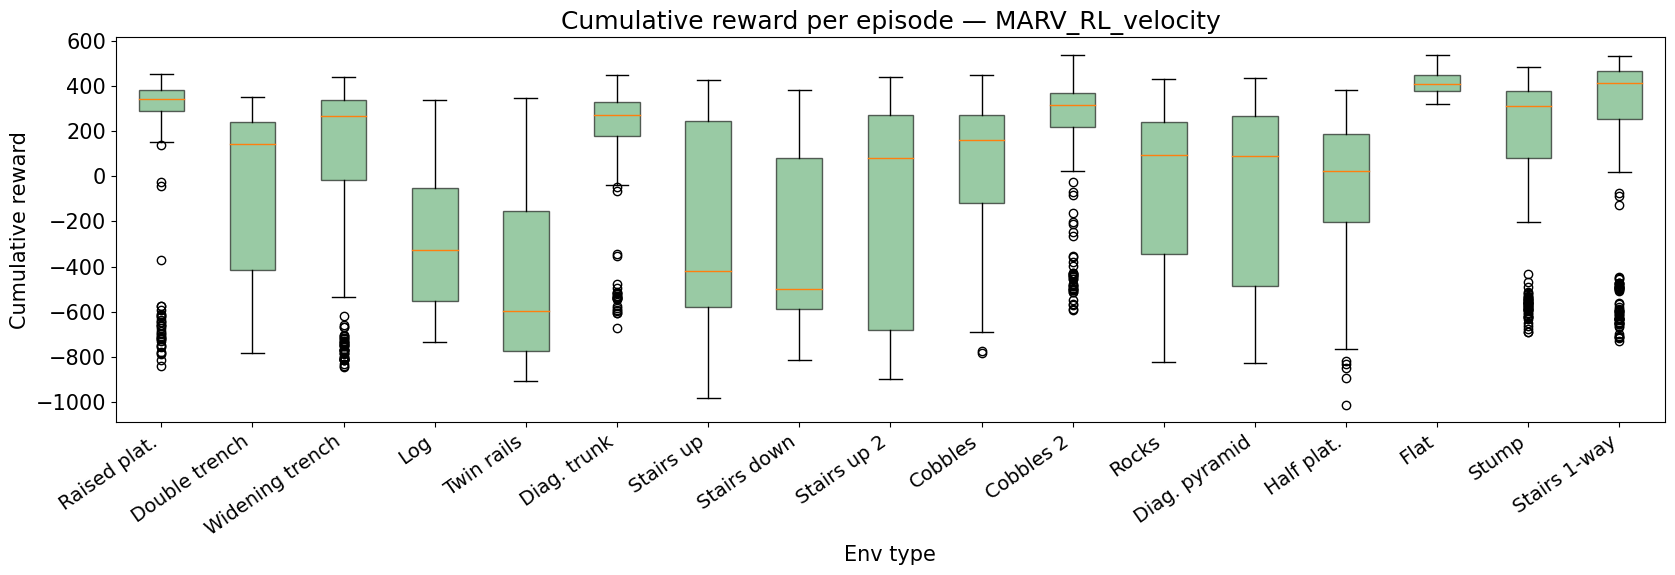

In [23]:
for ti, eids in terrain_groups(episodes_df):
    sub_all = episodes_df[episodes_df.eval_id.isin(eids)]
    env_order = sorted(sub_all["env_type_idx"].unique())
    for eid in eids:
        lbl = label_of(eid)
        sub = sub_all[sub_all.eval_id == eid]
        data = [sub[sub.env_type_idx == idx]["cumulative_reward"].dropna().values for idx in env_order]
        fig, ax = plt.subplots(figsize=(max(12, len(env_order)), 6))
        ax.boxplot(data, labels=[ti.short_of(i) for i in env_order],
                   patch_artist=True,
                   boxprops=dict(facecolor=LABEL_COLOR[lbl], alpha=0.6))
        ax.set_title(fig_title(ti, f"Cumulative reward per episode — {lbl}"))
        ax.set_xlabel("Env type")
        ax.set_ylabel("Cumulative reward")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()

## 7  Shock analysis

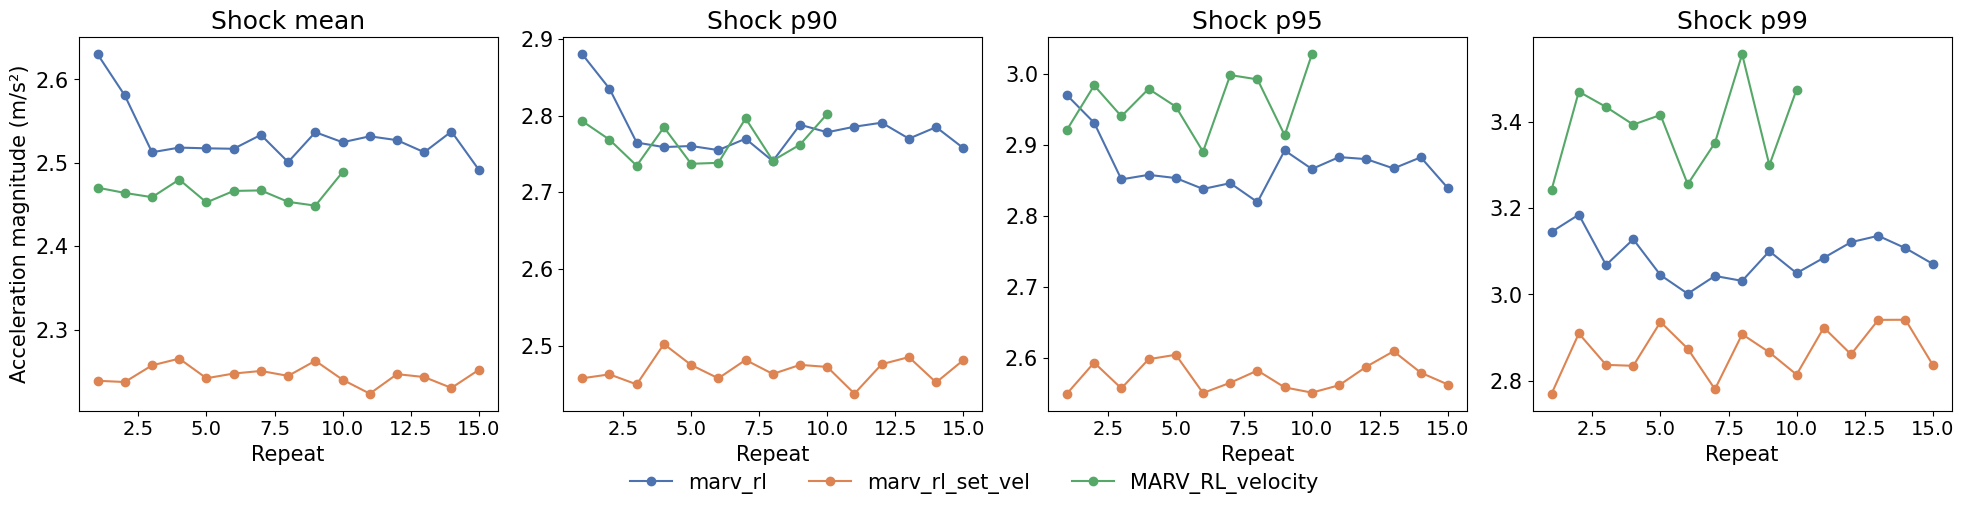

,shock_mean,shock_p90,shock_p95,shock_p99
label,,,,
MARV_RL_velocity,2.4649,2.7659,2.9605,3.3899
marv_rl,2.5315,2.7814,2.8723,3.0879
marv_rl_set_vel,2.2452,2.4685,2.5746,2.8689


In [24]:
shock_cols = ["shock_mean", "shock_p90", "shock_p95", "shock_p99"]
shock_present = [c for c in shock_cols if c in summary_df.columns and summary_df[c].notna().any()]

if not shock_present:
    print("No shock data in eval_summary.csv — run eval with shock reward enabled.")
else:
    for ti, eids in terrain_groups(summary_df):
        s_sub = summary_df[summary_df.eval_id.isin(eids)]
        fig, axes = plt.subplots(1, len(shock_present), figsize=(5 * len(shock_present), 5))
        if len(shock_present) == 1:
            axes = [axes]
        handles, labels_legend = [], []
        for ax, col in zip(axes, shock_present):
            for eid in eids:
                lbl = label_of(eid)
                sub = s_sub[s_sub.eval_id == eid].sort_values("repeat")
                line, = ax.plot(sub["repeat"], sub[col], marker="o",
                                color=LABEL_COLOR[lbl], label=lbl)
                if lbl not in labels_legend:
                    handles.append(line)
                    labels_legend.append(lbl)
            ax.set_title(col.replace("_", " ").replace("s", "S"))
            ax.set_xlabel("Repeat")
        axes[0].set_ylabel("Acceleration magnitude (m/s²)")
        fig.legend(handles, labels_legend, loc="lower center",
                   ncol=len(labels_legend), bbox_to_anchor=(0.5, -0.05), frameon=False)
        if len(TERRAIN_GROUPS) > 1:
            fig.suptitle(ti.name, fontsize=18, y=1.03)
        plt.tight_layout()
        #plt.savefig(fname=f"images/{ti.name}_shock_comp.svg", format="svg", bbox_inches="tight")
        plt.show()

        display(s_sub.groupby("label")[shock_present].mean().round(4))

## 8  Flipper posture per env type

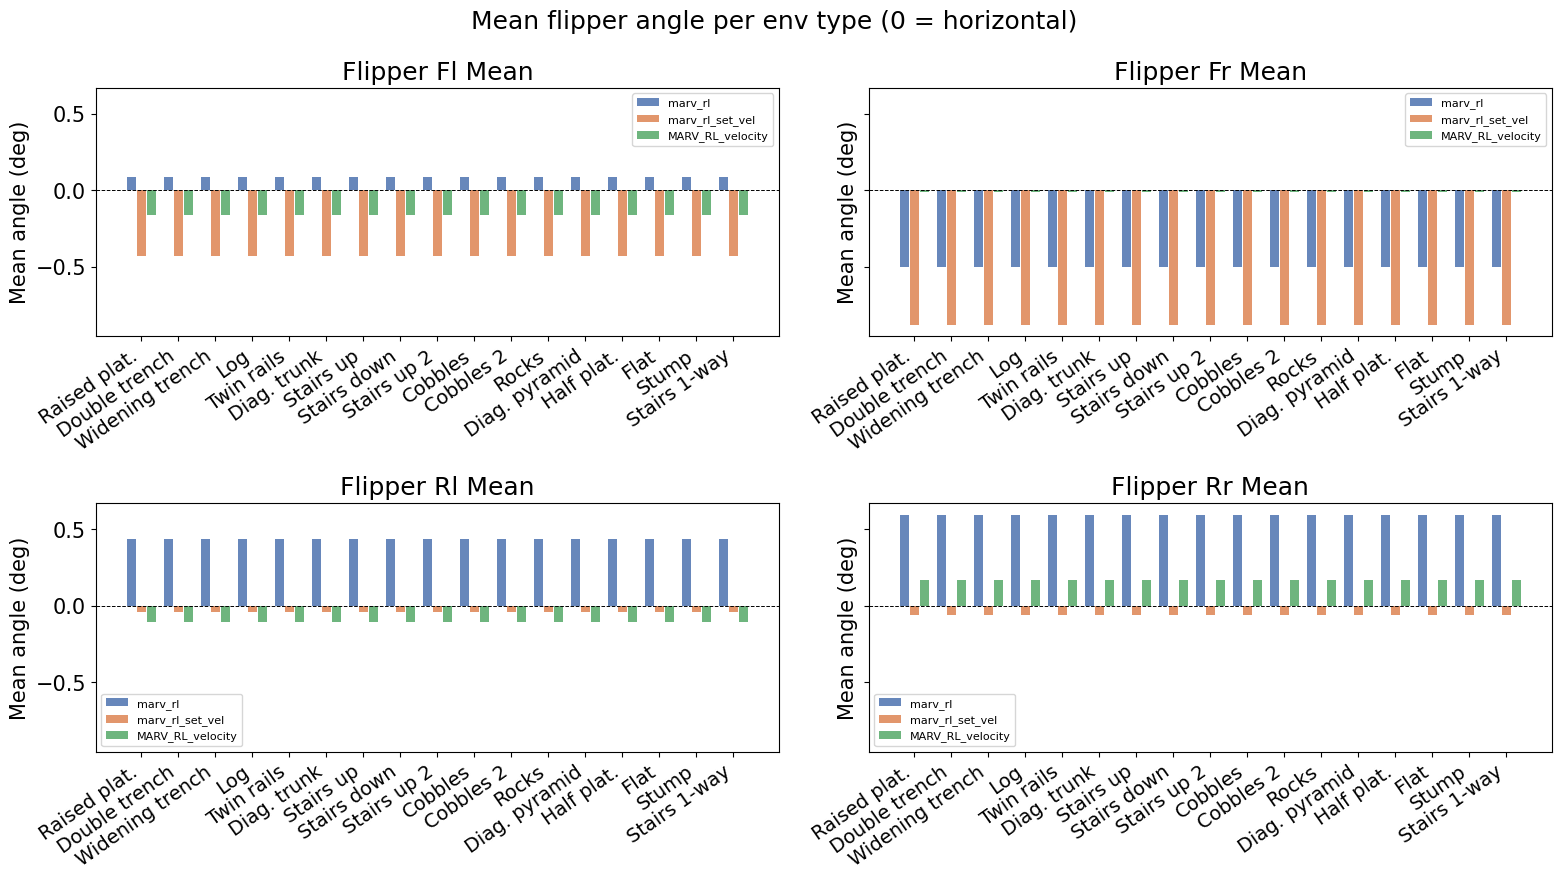

In [25]:
flipper_cols = ["flipper_fl_mean", "flipper_fr_mean", "flipper_rl_mean", "flipper_rr_mean"]
flipper_present = [c for c in flipper_cols if c in per_env_df.columns and per_env_df[c].notna().any()]

if not flipper_present:
    print("No flipper posture data in eval_per_env.csv.")
else:
    for ti, eids in terrain_groups(per_env_df):
        sub_all = per_env_df[per_env_df.eval_id.isin(eids)]
        env_order = sorted(sub_all["env_type_idx"].unique())
        x = np.arange(len(env_order))
        labels_x = [ti.short_of(i) for i in env_order]
        n_evals = len(eids)
        width = 0.8 / max(n_evals, 1)

        fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
        for ax, col in zip(axes.flat, flipper_cols):
            for ei, eid in enumerate(eids):
                lbl = label_of(eid)
                sub = sub_all[sub_all.eval_id == eid].groupby("env_type_idx")[col].mean()
                vals = [sub.get(idx, np.nan) for idx in env_order]
                offset = (ei - n_evals / 2 + 0.5) * width
                ax.bar(x + offset, np.rad2deg(vals), width=width * 0.9,
                       color=LABEL_COLOR[lbl], alpha=0.85, label=lbl)
            ax.set_title(col.replace("_", " ").title())
            ax.set_xticks(x)
            ax.set_xticklabels(labels_x, rotation=35, ha="right")
            ax.set_ylabel("Mean angle (deg)")
            ax.axhline(0, color="k", linewidth=0.7, linestyle="--")
            ax.legend(fontsize=8)
        plt.suptitle(fig_title(ti, "Mean flipper angle per env type (0 = horizontal)"))
        plt.tight_layout()
        plt.show()

## 9  Terrain heatmap — success rate per env type

One cell per course row, in course order.

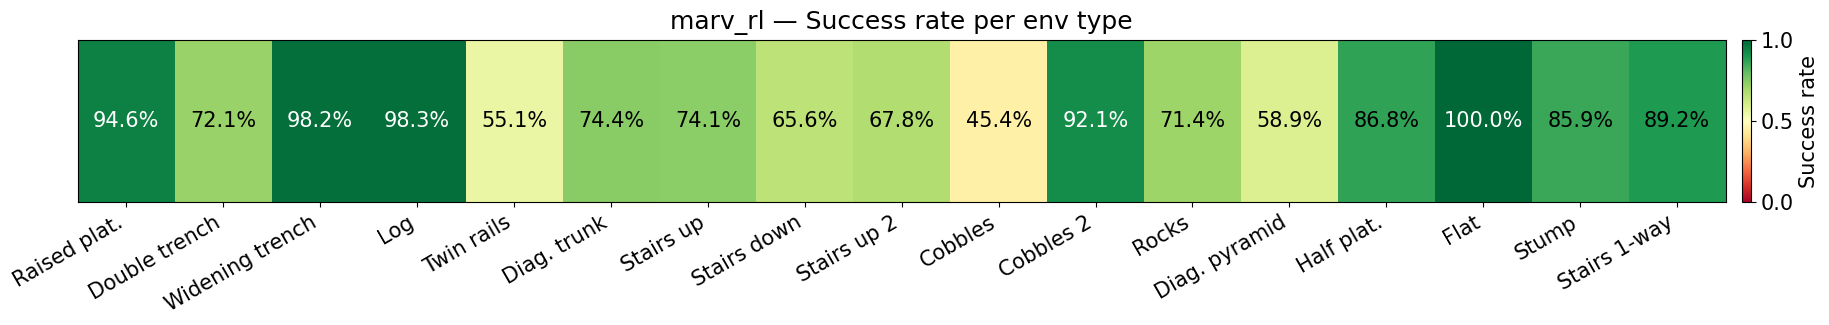

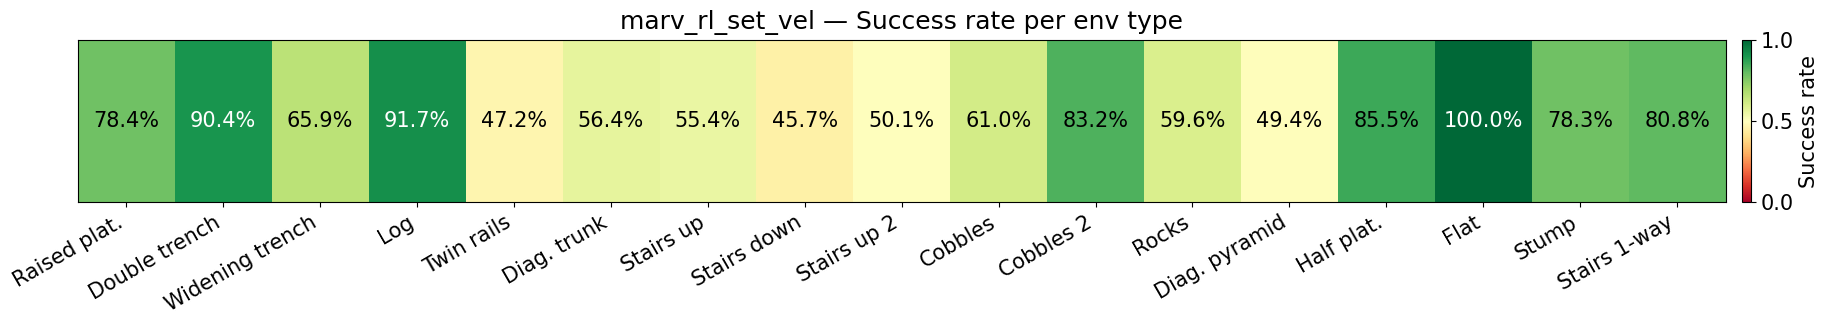

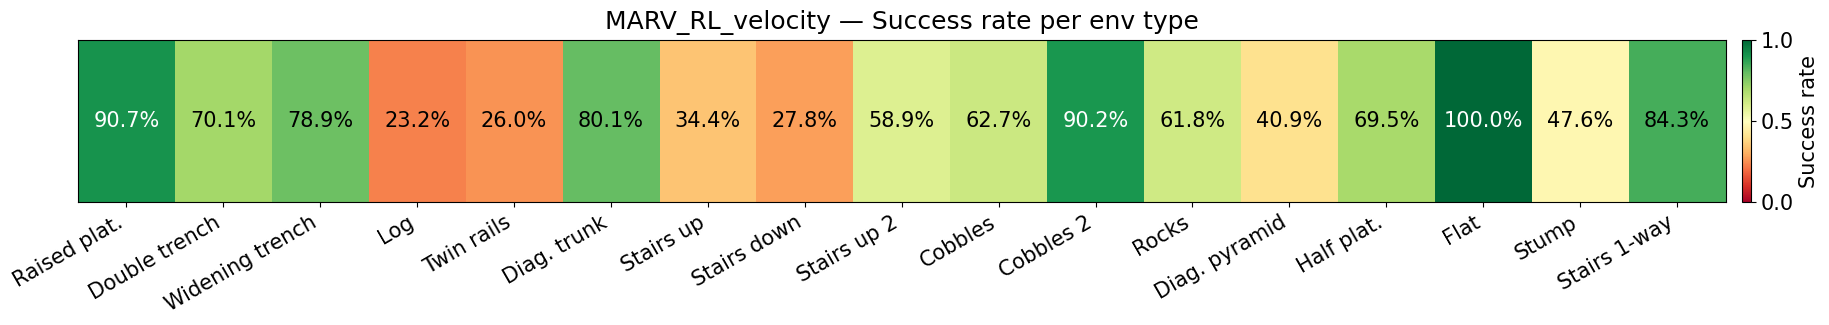

In [26]:
for ti, eids in terrain_groups(per_env_df):
    n = ti.num_env_types
    for eid in eids:
        lbl = label_of(eid)
        sub = per_env_df[per_env_df.eval_id == eid]
        sr = sub.groupby("env_type_idx")["success_rate"].mean()

        grid = np.full((1, n), np.nan)
        for idx in range(n):
            if idx in sr.index:
                grid[0, idx] = sr[idx]

        fig, ax = plt.subplots(figsize=(max(12, n * 1.1), 3.5))
        im = ax.imshow(grid, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")

        ax.set_xticks(range(n))
        ax.set_xticklabels(ti.short_names, fontsize=15, rotation=30, ha="right")
        ax.set_yticks([])
        if ti.sep_row is not None:
            ax.axvline(ti.sep_row - 0.5, color="black", linewidth=1.5, linestyle="--")

        ax.set_title(fig_title(ti, f"{lbl} — Success rate per env type"), pad=8, fontsize=18)

        for i in range(n):
            val = grid[0, i]
            if not np.isnan(val):
                ax.text(i, 0, f"{val:.1%}", ha="center", va="center", fontsize=15,
                        color="black" if 0.1 < val < 0.9 else "white")

        cbar = plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label="Success rate")
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Success rate", size=15)
        plt.tight_layout()
        plt.show()

## 10  Spot heatmap — success rate on the full spawn grid

Each cell is one unique birth position: rows = env type (course row), columns = depth column
(difficulty, easiest → hardest).

The heatmaps are drawn with **env type 0 at the bottom** and the terrain preview beside them
oriented to match (see section 3), so a heatmap row sits level with the terrain lane it came
from and a column sits above the tiles it scores.

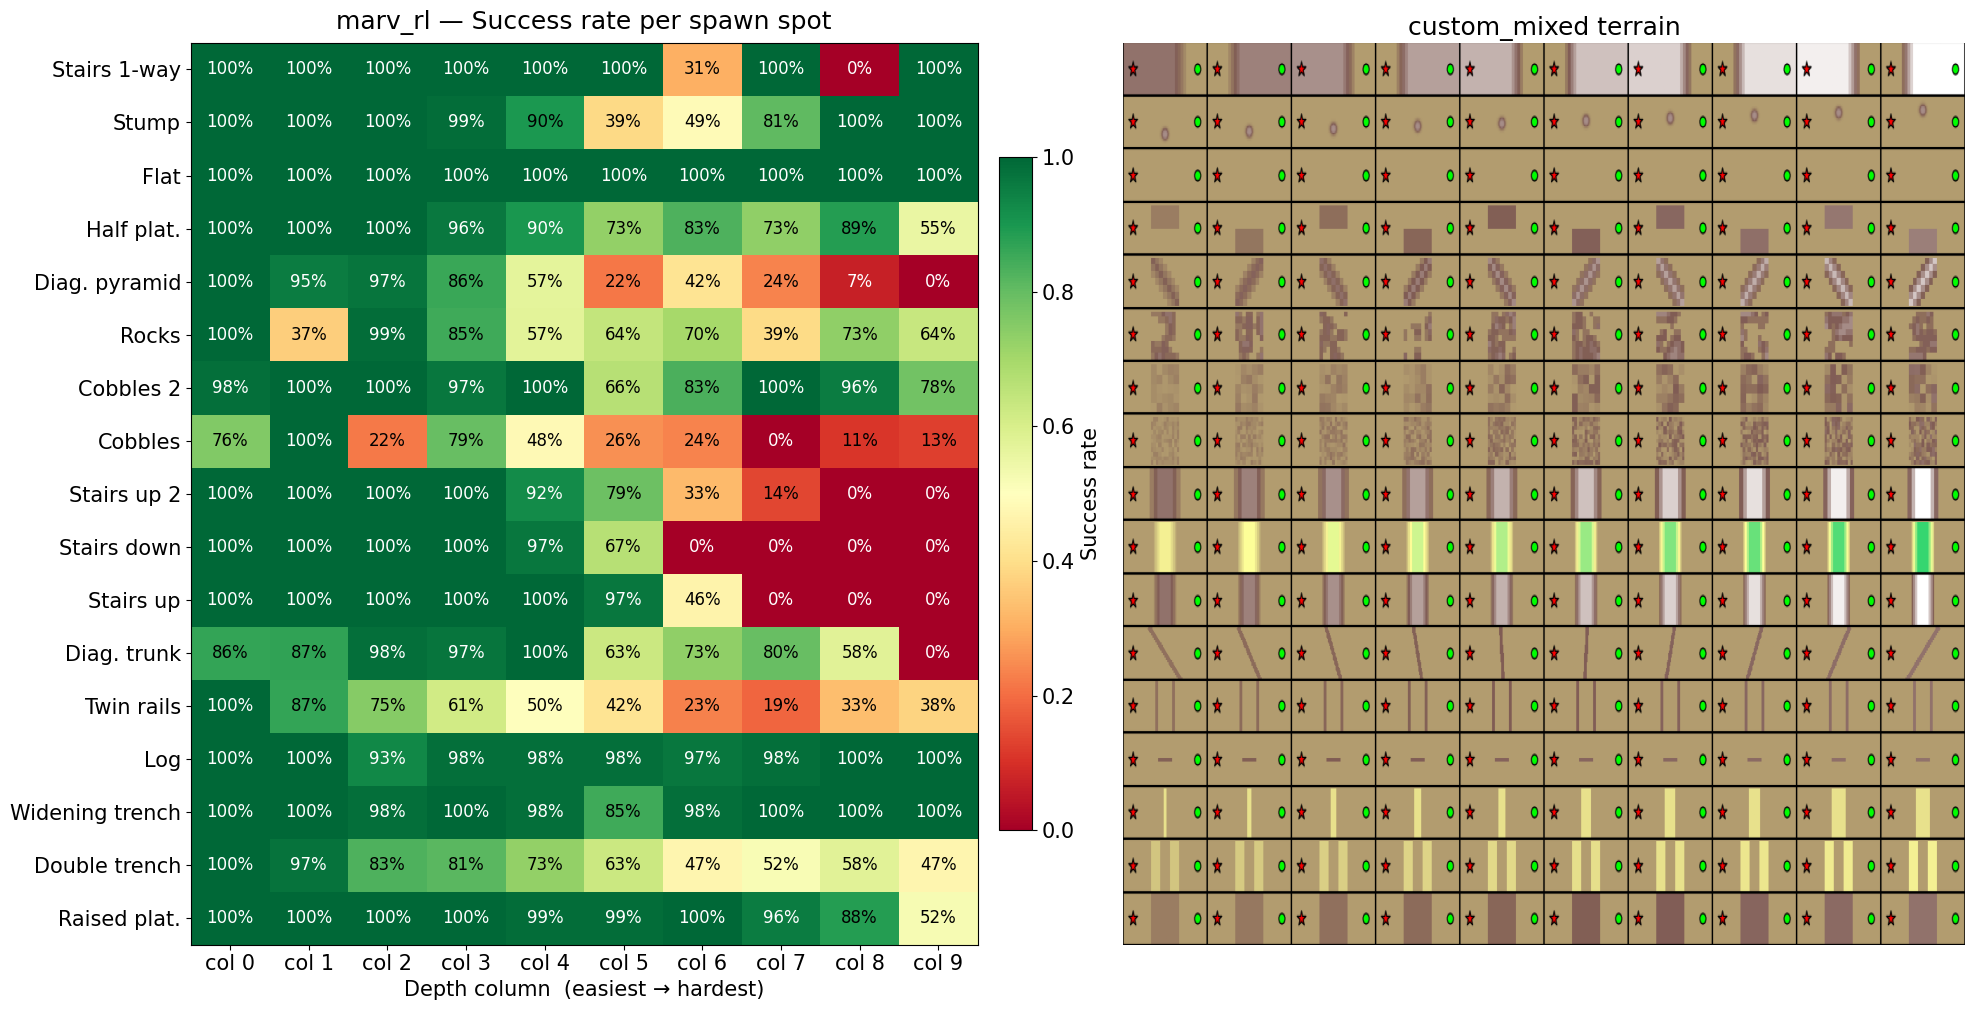

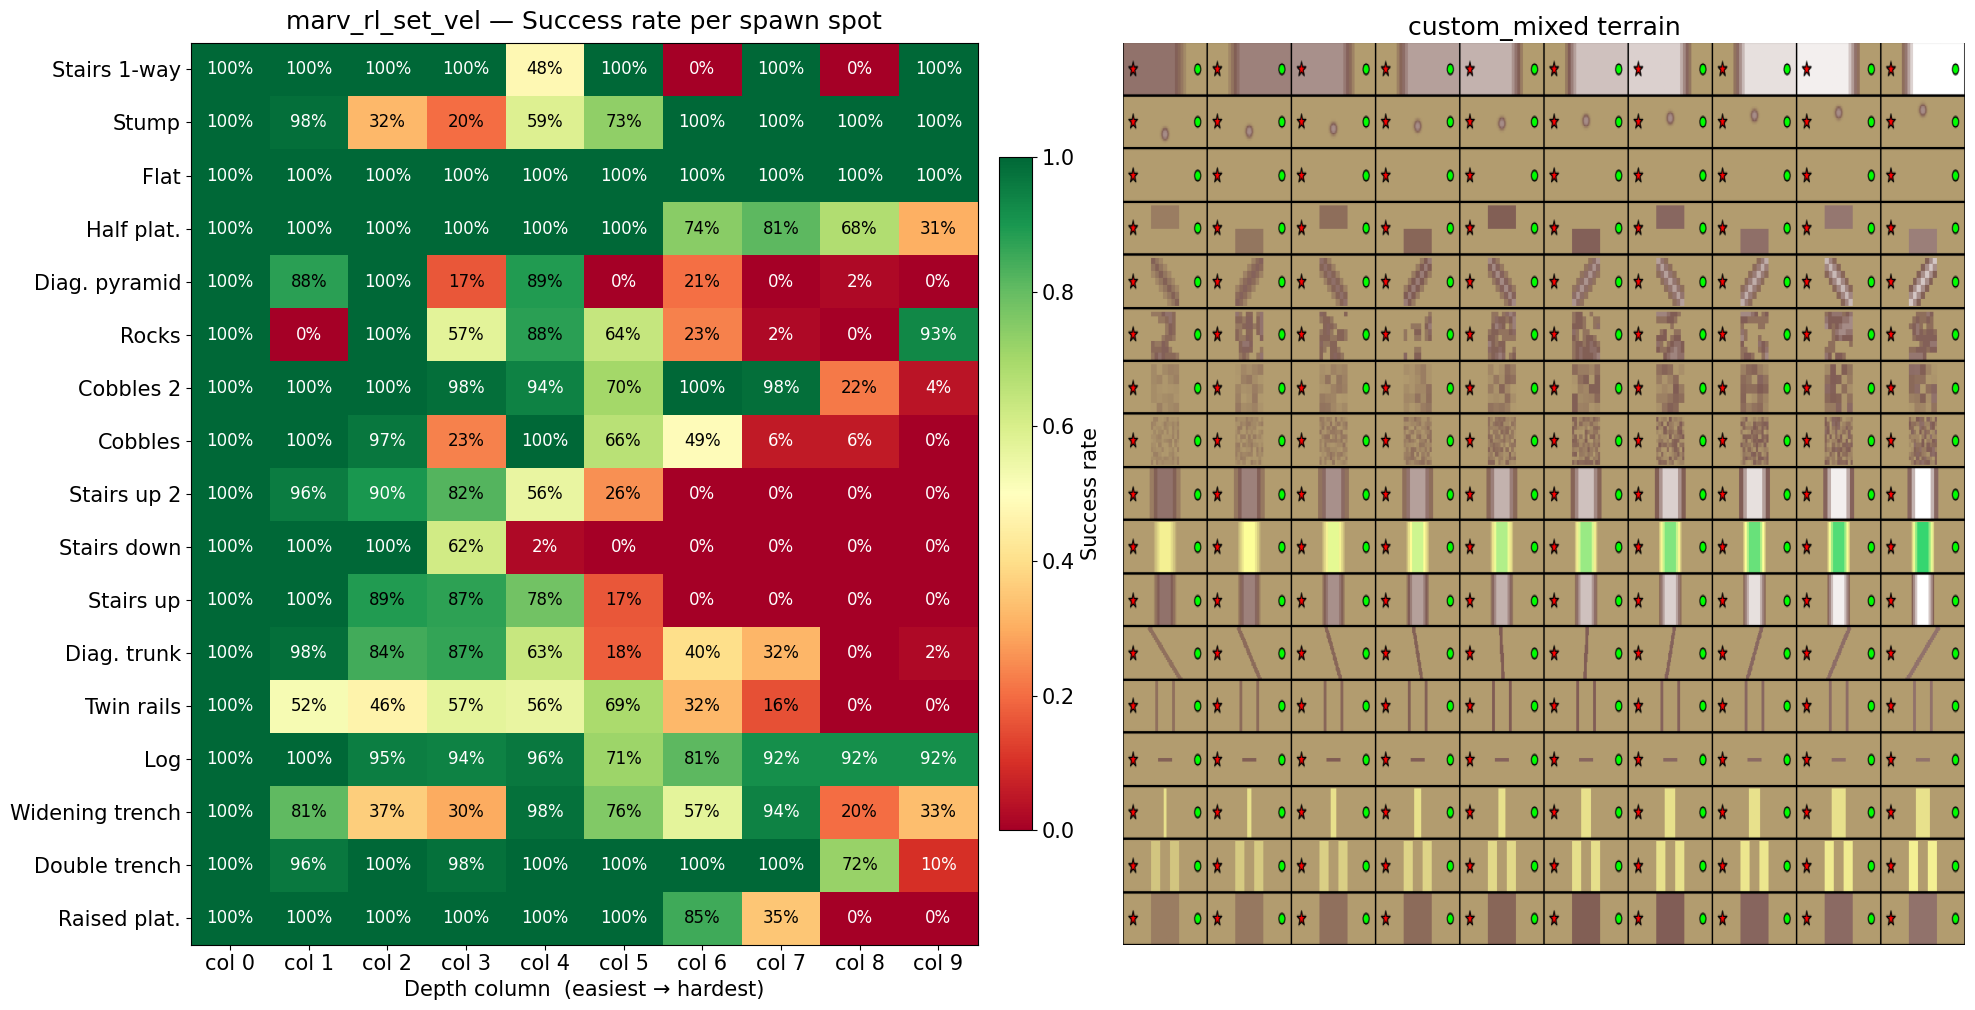

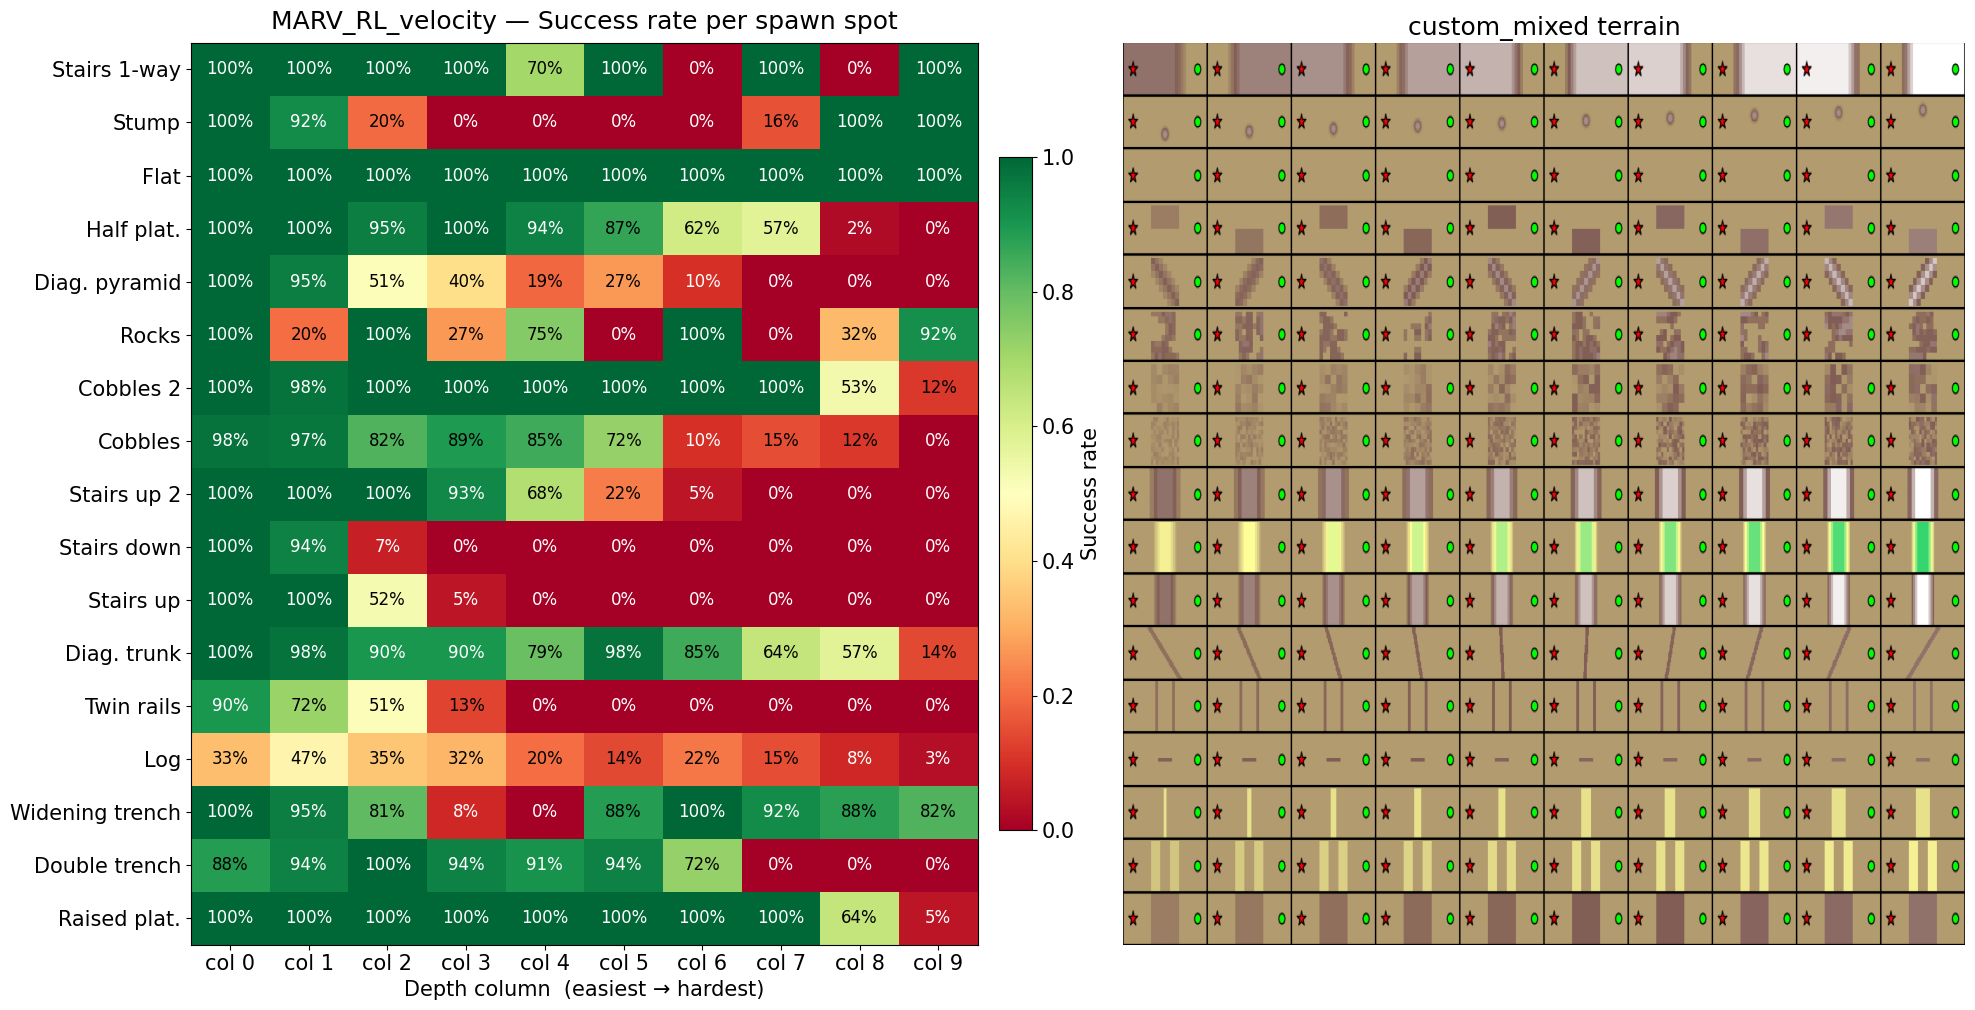

[info] custom_mixed: 3 evals — pairwise Δ plots need exactly 2.


In [27]:
def _spot_grid(df, eid, ti, value="success_rate", how="mean"):
    g = df[df.eval_id == eid].groupby(["env_type_idx", "depth_col"])[value]
    agg = g.mean() if how == "mean" else g.sum()
    grid = np.full((ti.num_env_types, ti.num_depth_cols), np.nan)
    for (env_idx, col), val in agg.items():
        if env_idx < ti.num_env_types and col < ti.num_depth_cols:
            grid[env_idx, col] = val
    return grid

def _spot_axes(ax, ti, title, show_ylabels=True):
    """Common spawn-grid axis setup: row 0 at the bottom, difficulty rising to the right."""
    ax.set_yticks(range(ti.num_env_types))
    ax.set_yticklabels(ti.short_names if show_ylabels else [], fontsize=15)
    ax.set_xticks(range(ti.num_depth_cols))
    ax.set_xticklabels([f"col {c}" for c in range(ti.num_depth_cols)], fontsize=15)
    ax.set_xlabel("Depth column  (easiest → hardest)", fontsize=15)
    ax.set_title(title, pad=10, fontsize=18)
    if ti.sep_row is not None:
        ax.axhline(ti.sep_row - 0.5, color="black", linewidth=1.5, linestyle="--")

def _spot_imshow(ax, grid, **kw):
    kw.setdefault("cmap", "RdYlGn")
    return ax.imshow(grid, aspect="auto", origin="lower", interpolation="nearest", **kw)

def _annotate_spot(ax, grid, fmt="{:.0%}", color_by_value=True, fontsize=12):
    for ei in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            val = grid[ei, c]
            if np.isnan(val):
                continue
            color = "black" if (not color_by_value or 0.1 < val < 0.9) else "white"
            ax.text(c, ei, fmt.format(val), ha="center", va="center", fontsize=fontsize, color=color)

def _add_preview(ax, ti):
    """Draw the terrain preview into *ax* (row 0 at the bottom, same as the heatmaps)."""
    if ti.preview is None:
        ax.axis("off")
        ax.text(0.5, 0.5, f"no preview for '{ti.name}'", ha="center", va="center", fontsize=14)
        return False
    ax.imshow(terrain_preview_image(ti), aspect="auto")
    ax.axis("off")
    note = " (rotated 180°)" if all(ti.preview_flip) else ""
    ax.set_title(f"{ti.name} terrain{note}", fontsize=18, pad=6)
    return True

def _spot_figsize(ti, ncols):
    return (ti.num_depth_cols * 0.9 * ncols + 2, ti.num_env_types * 0.55 + 1)

if per_spot_df is None:
    print("No eval_per_spot.csv found. Re-run eval to generate per-spot data.")
else:
    for ti, eids in terrain_groups(per_spot_df):
        # ── Individual plots (with terrain preview) ──────────────────────────
        for eid in eids:
            lbl = label_of(eid)
            grid = _spot_grid(per_spot_df, eid, ti)

            fig, (ax, ax_img) = plt.subplots(1, 2, figsize=_spot_figsize(ti, 2),
                                             gridspec_kw={"width_ratios": [1, 1]})
            im = _spot_imshow(ax, grid, vmin=0, vmax=1)
            _spot_axes(ax, ti, f"{lbl} — Success rate per spawn spot")
            _annotate_spot(ax, grid)

            cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.025)
            cbar.ax.tick_params(labelsize=15)
            cbar.set_label("Success rate", size=15)

            _add_preview(ax_img, ti)
            plt.tight_layout()
            #plt.savefig(fname=f"images/{eid}_{ti.name}_perspot_sr.svg", format="svg")
            plt.show()

        # ── Pairwise comparison (only within one terrain) ────────────────────
        if len(eids) != 2:
            if len(eids) > 2:
                print(f"[info] {ti.name}: {len(eids)} evals — pairwise Δ plots need exactly 2.")
            continue

        eid0, eid1 = eids
        lbl0, lbl1 = label_of(eid0), label_of(eid1)
        grid0 = _spot_grid(per_spot_df, eid0, ti)
        grid1 = _spot_grid(per_spot_df, eid1, ti)
        delta = grid0 - grid1   # positive = eid0 (better overall) wins

        # Side by side, one y-axis, one colorbar
        fig, (ax0, ax1) = plt.subplots(1, 2, figsize=_spot_figsize(ti, 2))
        for ax, grid, lbl, show_y in [(ax0, grid0, lbl0, True), (ax1, grid1, lbl1, False)]:
            im = _spot_imshow(ax, grid, vmin=0, vmax=1)
            _spot_axes(ax, ti, lbl, show_ylabels=show_y)
            _annotate_spot(ax, grid)
        cbar = fig.colorbar(im, ax=ax1, fraction=0.04, pad=0.025)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Success rate", size=15)
        fig.suptitle(fig_title(ti, "Success rate per spawn spot — comparison"), fontsize=18, y=1.01)
        plt.tight_layout()
        #plt.savefig(fname=f"images/{eid0}_{eid1}_perspot_sr_comp.svg", format="svg", bbox_inches="tight")
        plt.show()

        # Delta heatmap with terrain preview
        fig, (ax_delta, ax_img) = plt.subplots(1, 2, figsize=_spot_figsize(ti, 2),
                                               gridspec_kw={"width_ratios": [1, 1]})
        im_d = _spot_imshow(ax_delta, delta, vmin=-1, vmax=1)
        _spot_axes(ax_delta, ti, f"Δ success rate  ({lbl0} − {lbl1})")
        _annotate_spot(ax_delta, delta, fmt="{:+.0%}", color_by_value=False)
        cbar_d = plt.colorbar(im_d, ax=ax_delta, fraction=0.04, pad=0.025)
        cbar_d.ax.tick_params(labelsize=15)
        cbar_d.set_label("Δ Success rate", size=15)
        _add_preview(ax_img, ti)
        plt.tight_layout()
        #plt.savefig(fname=f"images/{eid0}_{eid1}_perspot_delta.svg", format="svg")
        plt.show()

        # Best + delta side by side
        fig, (ax_best, ax_diff) = plt.subplots(1, 2, figsize=_spot_figsize(ti, 2))
        im_best = _spot_imshow(ax_best, grid0, vmin=0, vmax=1)
        _spot_axes(ax_best, ti, lbl0)
        _annotate_spot(ax_best, grid0)
        cbar_best = plt.colorbar(im_best, ax=ax_best, fraction=0.04, pad=0.025)
        cbar_best.ax.tick_params(labelsize=15)
        cbar_best.set_label("Success rate", size=15)

        im_diff = _spot_imshow(ax_diff, delta, vmin=-1, vmax=1)
        _spot_axes(ax_diff, ti, f"Δ  ({lbl0} − {lbl1})", show_ylabels=False)
        _annotate_spot(ax_diff, delta, fmt="{:+.0%}", color_by_value=False)
        cbar_diff = plt.colorbar(im_diff, ax=ax_diff, fraction=0.04, pad=0.025)
        cbar_diff.ax.tick_params(labelsize=15)
        cbar_diff.set_label("Δ Success rate", size=15)
        plt.tight_layout()
        #plt.savefig(fname=f"images/{eid0}_{eid1}_perspot_best_delta.svg", format="svg")
        plt.show()

## 10b  Weight-averaged blend — delta vs. both originals

Set the three `eval_id` strings below. All three must have run on the **same terrain**.
**Left:** `BLEND − ORIG_A` · **Right:** `BLEND − ORIG_B`
Green = blend wins · Red = original wins.

In [28]:
# ── CONFIG ── set these to the eval_id strings from the Load cell output ──────
BLEND_EVAL_ID  = "avaraged_local"   # the weight-averaged policy
ORIG_A_EVAL_ID = "best_long"        # first original  (e.g. long-trained)
ORIG_B_EVAL_ID = "best"             # second original (e.g. short-trained)
COVERAGE_THRESHOLD = 0.70           # success rate threshold for coverage metric
# ─────────────────────────────────────────────────────────────────────────────

_trio = [BLEND_EVAL_ID, ORIG_A_EVAL_ID, ORIG_B_EVAL_ID]

if per_spot_df is None:
    print("No eval_per_spot.csv found — re-run eval to generate per-spot data.")
else:
    _available = per_spot_df["eval_id"].unique()
    _missing = [e for e in _trio if e not in _available]
    _terrains = {TERRAIN_OF.get(e) for e in _trio if e in _available}
    if _missing:
        print(f"Missing eval_id(s) in per_spot_df: {_missing}")
        print(f"Available: {list(_available)}")
    elif len(_terrains) > 1:
        print("These three evals ran on different terrains "
              f"({', '.join(sorted(map(str, _terrains)))}) — a blend can only be compared "
              "against originals evaluated on the same course.")
    else:
        ti = TERRAINS[TERRAIN_OF[BLEND_EVAL_ID]]
        g_blend  = _spot_grid(per_spot_df, BLEND_EVAL_ID,  ti)
        g_orig_a = _spot_grid(per_spot_df, ORIG_A_EVAL_ID, ti)
        g_orig_b = _spot_grid(per_spot_df, ORIG_B_EVAL_ID, ti)

        delta_a = g_blend - g_orig_a
        delta_b = g_blend - g_orig_b

        lbl_blend, lbl_a, lbl_b = (label_of(e) for e in _trio)

        # ── Three success-rate heatmaps side by side ──────────────────────────
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=_spot_figsize(ti, 3))
        for ax, grid, title, show_y in [
            (ax1, g_orig_a, lbl_a,     True),
            (ax2, g_blend,  lbl_blend, False),
            (ax3, g_orig_b, lbl_b,     False),
        ]:
            im = _spot_imshow(ax, grid, vmin=0, vmax=1)
            _spot_axes(ax, ti, title, show_ylabels=show_y)
            _annotate_spot(ax, grid)
        cbar = fig.colorbar(im, ax=ax3, fraction=0.04, pad=0.025)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Success rate", size=15)
        fig.suptitle(fig_title(ti, "Success rate per spawn spot — all three policies"), fontsize=18, y=1.01)
        plt.tight_layout()
        #plt.savefig(fname=f"images/{ti.name}_avg_three_perspot_sr.svg", format="svg", bbox_inches="tight")
        plt.show()

        # ── Two delta maps side by side ───────────────────────────────────────
        fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=_spot_figsize(ti, 2))
        for ax, delta, orig_lbl, show_y in [
            (ax_a, delta_a, lbl_a, True),
            (ax_b, delta_b, lbl_b, False),
        ]:
            im = _spot_imshow(ax, delta, vmin=-1, vmax=1)
            _spot_axes(ax, ti, f"Δ  ({lbl_blend} − {orig_lbl})", show_ylabels=show_y)
            _annotate_spot(ax, delta, fmt="{:+.0%}", color_by_value=False)
        cbar = fig.colorbar(im, ax=ax_b, fraction=0.04, pad=0.025)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Δ Success rate", size=15)
        fig.suptitle(fig_title(ti, f"Blend performance: {lbl_blend}"), fontsize=18, y=1.01)
        plt.tight_layout()
        #plt.savefig(fname=f"images/{ti.name}_avg_perspot_delta.svg", format="svg", bbox_inches="tight")
        plt.show()

        # ── Blend + both deltas (3-panel) ─────────────────────────────────────
        fig, (ax_bl, ax_da, ax_db) = plt.subplots(1, 3, figsize=_spot_figsize(ti, 3))
        im_bl = _spot_imshow(ax_bl, g_blend, vmin=0, vmax=1)
        _spot_axes(ax_bl, ti, lbl_blend)
        _annotate_spot(ax_bl, g_blend)
        cbar_bl = plt.colorbar(im_bl, ax=ax_bl, fraction=0.04, pad=0.025)
        cbar_bl.ax.tick_params(labelsize=15)
        cbar_bl.set_label("Success rate", size=15)

        for ax, delta, orig_lbl in [(ax_da, delta_a, lbl_a), (ax_db, delta_b, lbl_b)]:
            im_d = _spot_imshow(ax, delta, vmin=-1, vmax=1)
            _spot_axes(ax, ti, f"Δ vs {orig_lbl}", show_ylabels=False)
            _annotate_spot(ax, delta, fmt="{:+.0%}", color_by_value=False)
        cbar_d = plt.colorbar(im_d, ax=ax_db, fraction=0.04, pad=0.025)
        cbar_d.ax.tick_params(labelsize=15)
        cbar_d.set_label("Δ Success rate", size=15)
        fig.suptitle(fig_title(ti, f"Blend vs. originals — {lbl_blend}"), fontsize=18, y=1.01)
        plt.tight_layout()
        plt.show()

        # ── Generalization metrics ────────────────────────────────────────────
        # 1. Categorical dominance map
        TIE_EPS = 0.05
        dom = np.full((ti.num_env_types, ti.num_depth_cols), np.nan)
        for ei in range(ti.num_env_types):
            for c in range(ti.num_depth_cols):
                va, vbl, vb = g_orig_a[ei, c], g_blend[ei, c], g_orig_b[ei, c]
                if np.isnan(va) or np.isnan(vbl) or np.isnan(vb):
                    continue
                best = max(va, vbl, vb)
                winners = [v for v in [va, vbl, vb] if best - v < TIE_EPS]
                if len(winners) > 1:
                    dom[ei, c] = 3
                elif va == best:
                    dom[ei, c] = 0
                elif vbl == best:
                    dom[ei, c] = 1
                else:
                    dom[ei, c] = 2

        dom_colors = ["#4C72B0", "#55A868", "#DD8452", "#BBBBBB"]
        dom_labels = [lbl_a, lbl_blend, lbl_b, "Tie (≤5 pp)"]
        dom_cmap = plt.matplotlib.colors.ListedColormap(dom_colors)

        fig, ax = plt.subplots(figsize=_spot_figsize(ti, 1))
        im = _spot_imshow(ax, dom, cmap=dom_cmap, vmin=-0.5, vmax=3.5)
        _spot_axes(ax, ti, fig_title(ti, "Dominant policy per spawn spot"))
        cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], fraction=0.04, pad=0.025)
        cbar.ax.set_yticklabels(dom_labels, fontsize=14)
        counts = {lbl: int(np.sum(dom == i)) for i, lbl in enumerate(dom_labels)}
        total = sum(counts.values())
        count_str = "  |  ".join(f"{lbl}: {n} ({n/total:.0%})" for lbl, n in counts.items())
        ax.set_xlabel(f"Depth column  (easiest → hardest)\n{count_str}", fontsize=14)
        plt.tight_layout()
        plt.show()

        # 2. Floor-lift map
        floor_lift = g_blend - np.fmin(g_orig_a, g_orig_b)

        fig, ax = plt.subplots(figsize=_spot_figsize(ti, 1))
        im = _spot_imshow(ax, floor_lift, vmin=-1, vmax=1)
        _spot_axes(ax, ti, f"Floor-lift: {lbl_blend} − min({lbl_a}, {lbl_b})\n"
                           f"Green = blend rescued a weak spot · Red = blend fell below both parents")
        ax.title.set_fontsize(16)
        _annotate_spot(ax, floor_lift, fmt="{:+.0%}", color_by_value=False)
        cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.025)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Blend − min(parents)", size=15)
        plt.tight_layout()
        plt.show()

        # 3. Coverage & consistency per env type
        def _coverage(grid, thr):
            return np.nanmean(grid > thr, axis=1)

        def _consistency(grid):
            return np.nanstd(grid, axis=1)

        cov_a, cov_blend, cov_b = (_coverage(g, COVERAGE_THRESHOLD) for g in (g_orig_a, g_blend, g_orig_b))
        std_a, std_blend, std_b = (_consistency(g) for g in (g_orig_a, g_blend, g_orig_b))

        x = np.arange(ti.num_env_types)
        w = 0.25

        fig, (ax_cov, ax_std) = plt.subplots(2, 1, figsize=(max(14, ti.num_env_types), 10))
        for ax, vals_a, vals_blend, vals_b, ylabel, title in [
            (ax_cov, cov_a, cov_blend, cov_b,
             f"Fraction of depth cols with SR > {COVERAGE_THRESHOLD:.0%}",
             f"Coverage (success > {COVERAGE_THRESHOLD:.0%}) per env type"),
            (ax_std, std_a, std_blend, std_b,
             "Std of success rate across depth cols  (lower = more consistent)",
             "Depth-column consistency per env type"),
        ]:
            ax.bar(x - w, vals_a,     width=w, color=LABEL_COLOR.get(lbl_a,     PALETTE[0]), alpha=0.85, label=lbl_a)
            ax.bar(x,     vals_blend, width=w, color=LABEL_COLOR.get(lbl_blend, PALETTE[1]), alpha=0.85, label=lbl_blend)
            ax.bar(x + w, vals_b,     width=w, color=LABEL_COLOR.get(lbl_b,     PALETTE[2]), alpha=0.85, label=lbl_b)
            ax.set_xticks(x)
            ax.set_xticklabels(ti.short_names, rotation=35, ha="right", fontsize=14)
            ax.set_ylabel(ylabel, fontsize=14)
            ax.set_title(fig_title(ti, title), fontsize=18)
            ax.legend(fontsize=14)
            if ti.sep_row is not None:
                ax.axvline(ti.sep_row - 0.5, color="black", linewidth=1, linestyle="--")
        plt.tight_layout()
        plt.show()

Missing eval_id(s) in per_spot_df: ['avaraged_local', 'best_long', 'best']
Available: ['MARV_RL_velocity', 'marv_rl', 'marv_rl_set_vel']


## 10c  Episode count comparison — per env type and per spot

Checks how many episodes each eval collected at every location. Uneven counts indicate robots that were reset more often (harder spots) or missing data.

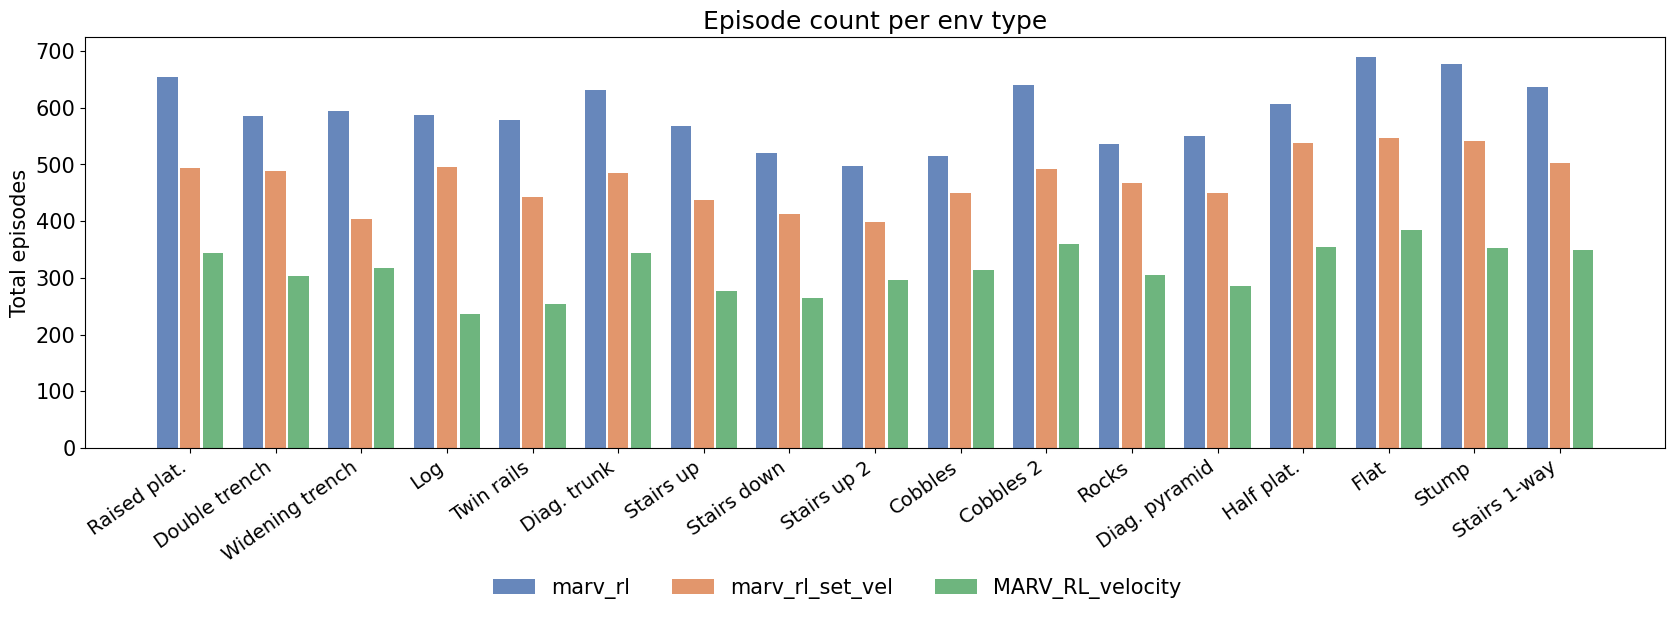

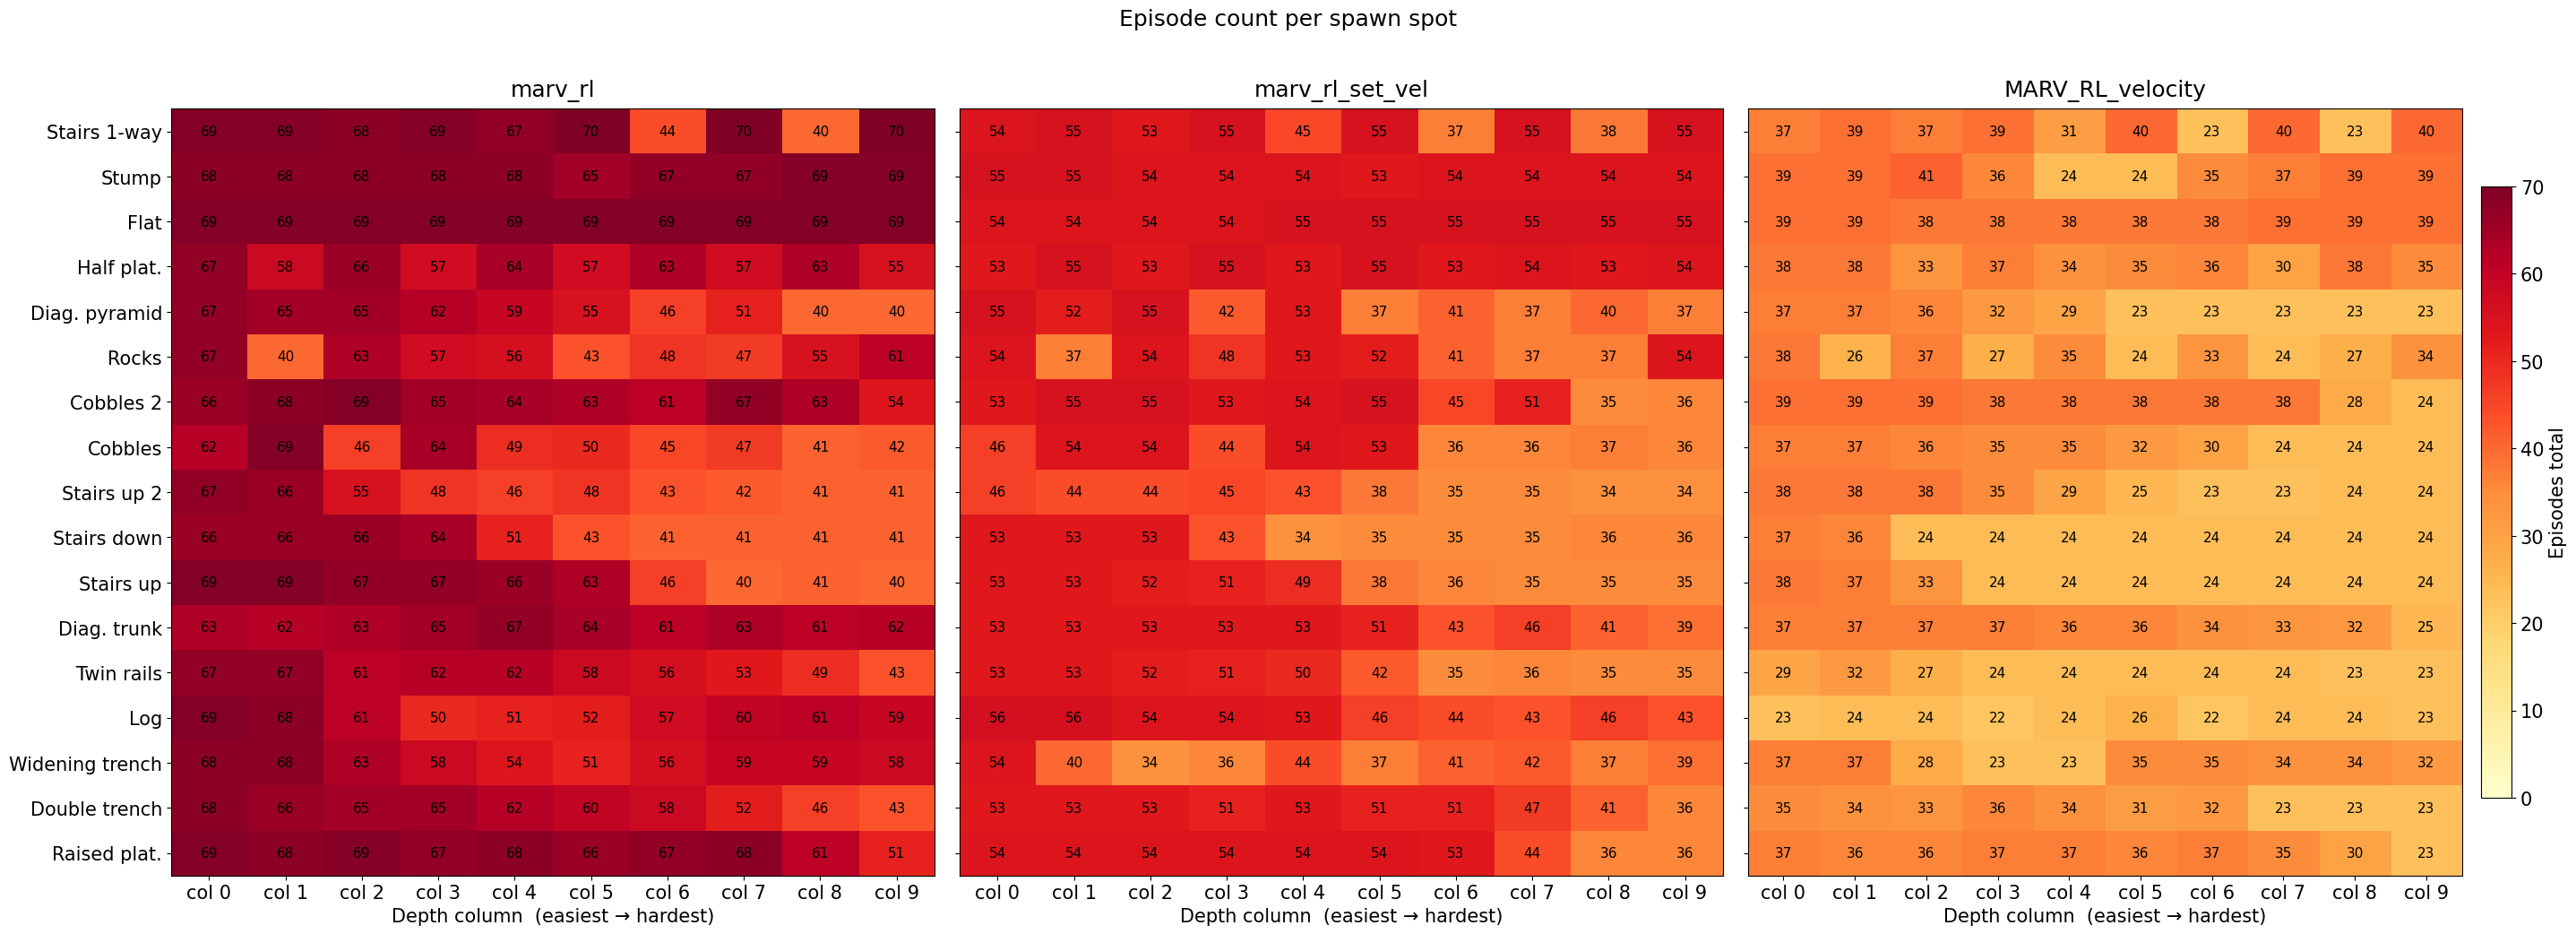

In [29]:
# ── Per-env-type episode count (bar chart) ────────────────────────────────────
for ti, eids in terrain_groups(per_env_df):
    sub_all = per_env_df[per_env_df.eval_id.isin(eids)]
    env_order = sorted(sub_all["env_type_idx"].unique())
    x = np.arange(len(env_order))
    n_evals = len(eids)
    width = 0.8 / max(n_evals, 1)

    fig, ax = plt.subplots(figsize=(max(14, len(env_order)), 6))
    handles, labels_legend = [], []
    for ei, eid in enumerate(eids):
        lbl = label_of(eid)
        sub = sub_all[sub_all.eval_id == eid].groupby("env_type_idx")["episodes_total"].sum()
        vals = [sub.get(idx, 0) for idx in env_order]
        offset = (ei - n_evals / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width=width * 0.9,
                      color=LABEL_COLOR[lbl], alpha=0.85, label=lbl)
        handles.append(bars)
        labels_legend.append(lbl)

    ax.set_xticks(x)
    ax.set_xticklabels([ti.short_of(i) for i in env_order], rotation=35, ha="right")
    ax.set_ylabel("Total episodes")
    ax.set_title(fig_title(ti, "Episode count per env type"))
    fig.legend(handles, labels_legend, loc="lower center",
               ncol=n_evals, bbox_to_anchor=(0.5, -0.05), frameon=False)
    plt.tight_layout()
    plt.show()

# ── Per-spot episode count heatmaps ──────────────────────────────────────────
if per_spot_df is None:
    print("No eval_per_spot.csv found — episode count heatmaps unavailable.")
else:
    for ti, eids in terrain_groups(per_spot_df):
        grids = {eid: _spot_grid(per_spot_df, eid, ti, value="episodes_total", how="sum")
                 for eid in eids}
        vmax = max(np.nanmax(g) for g in grids.values()) if grids else 1

        n_plots = len(eids)
        fig, axes = plt.subplots(1, n_plots, figsize=_spot_figsize(ti, n_plots), squeeze=False)
        im = None
        for i, eid in enumerate(eids):
            ax = axes[0, i]
            grid = grids[eid]
            im = _spot_imshow(ax, grid, cmap="YlOrRd", vmin=0, vmax=vmax)
            _spot_axes(ax, ti, label_of(eid), show_ylabels=(i == 0))
            _annotate_spot(ax, grid, fmt="{:.0f}", color_by_value=False, fontsize=11)
        if im is not None:
            cbar = fig.colorbar(im, ax=axes[0, -1], fraction=0.04, pad=0.025)
            cbar.ax.tick_params(labelsize=15)
            cbar.set_label("Episodes total", size=15)
        fig.suptitle(fig_title(ti, "Episode count per spawn spot"), fontsize=18, y=1.01)
        plt.tight_layout()
        plt.show()

        # ── Delta episode count (only when exactly 2 evals on this terrain) ──
        if len(eids) != 2:
            continue
        eid0, eid1 = eids
        delta_ep = grids[eid1] - grids[eid0]
        abs_max = np.nanmax(np.abs(delta_ep))

        fig, ax = plt.subplots(figsize=_spot_figsize(ti, 1))
        im = _spot_imshow(ax, delta_ep, vmin=-abs_max, vmax=abs_max)
        _spot_axes(ax, ti, f"Δ episodes  ({label_of(eid1)} − {label_of(eid0)})")
        _annotate_spot(ax, delta_ep, fmt="{:+.0f}", color_by_value=False, fontsize=11)
        cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.025)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Δ Episodes", size=15)
        plt.tight_layout()
        plt.show()

## 11  Episode distributions — step-count histogram & dist-to-goal CDF at failure

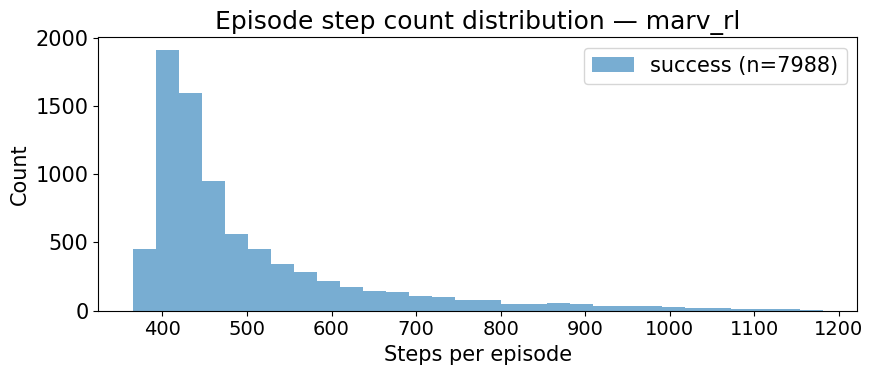

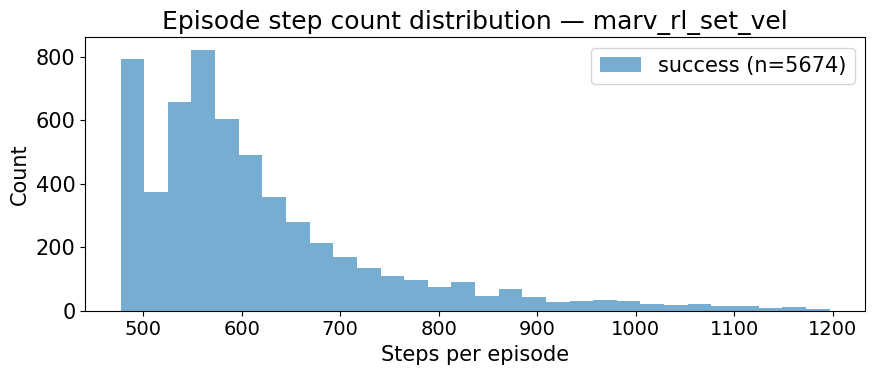

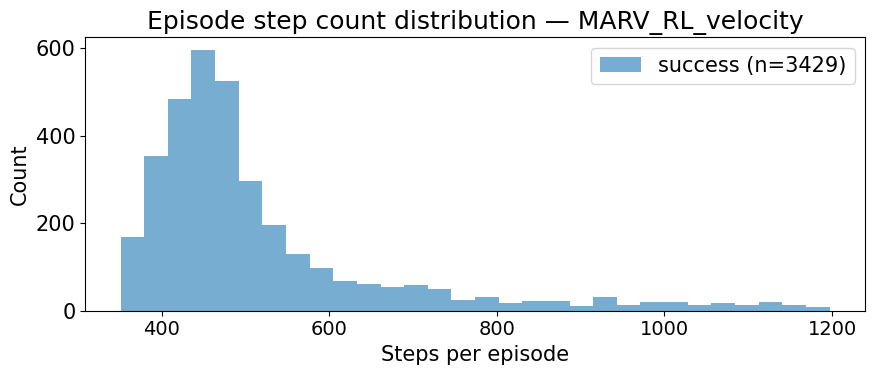

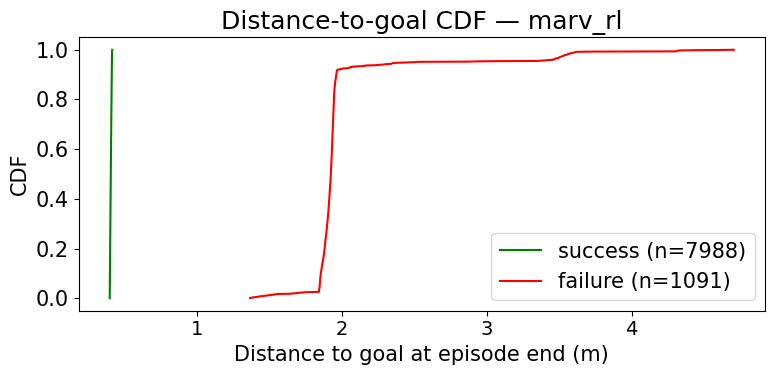

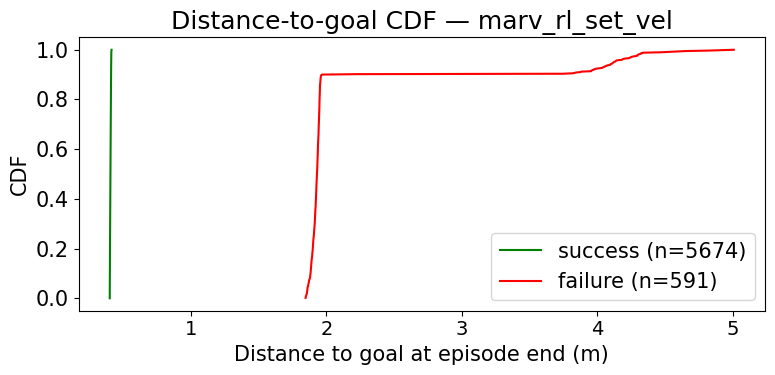

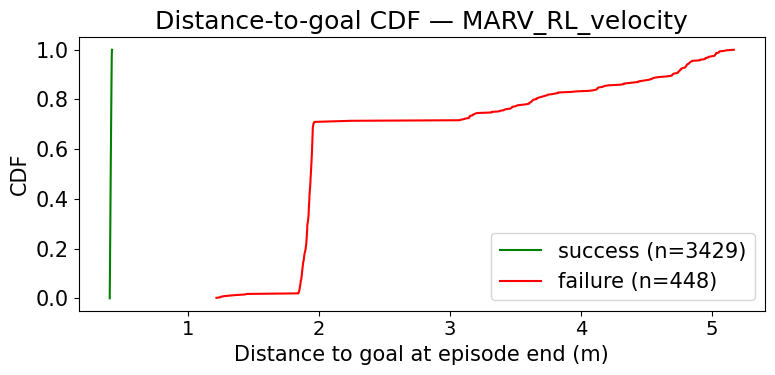

In [30]:
# Step-count histogram per outcome
for ti, eids in terrain_groups(episodes_df):
    for eid in eids:
        lbl = label_of(eid)
        sub = episodes_df[episodes_df.eval_id == eid]
        fig, ax = plt.subplots(figsize=(9, 4))
        for outcome in ["success"]:
            vals = sub[sub.outcome == outcome]["steps"].values
            if len(vals) > 0:
                ax.hist(vals, bins=30, alpha=0.6, label=f"{outcome} (n={len(vals)})")
        ax.set_xlabel("Steps per episode")
        ax.set_ylabel("Count")
        ax.set_title(fig_title(ti, f"Episode step count distribution — {lbl}"))
        ax.legend()
        plt.tight_layout()
        plt.show()

# Distance-to-goal CDF at episode end, split by outcome
for ti, eids in terrain_groups(episodes_df):
    for eid in eids:
        lbl = label_of(eid)
        sub = episodes_df[episodes_df.eval_id == eid]
        fig, ax = plt.subplots(figsize=(8, 4))
        for outcome, color in [("success", "green"), ("failure", "red"), ("explosion", "orange")]:
            vals = np.sort(sub[sub.outcome == outcome]["dist_to_goal_final"].dropna().values)
            if len(vals) > 0:
                cdf = np.arange(1, len(vals)+1) / len(vals)
                ax.plot(vals, cdf, label=f"{outcome} (n={len(vals)})", color=color)
        ax.set_xlabel("Distance to goal at episode end (m)")
        ax.set_ylabel("CDF")
        ax.set_title(fig_title(ti, f"Distance-to-goal CDF — {lbl}"))
        ax.legend()
        plt.tight_layout()
        plt.show()

## 12  Multi-eval comparison — side-by-side success rate

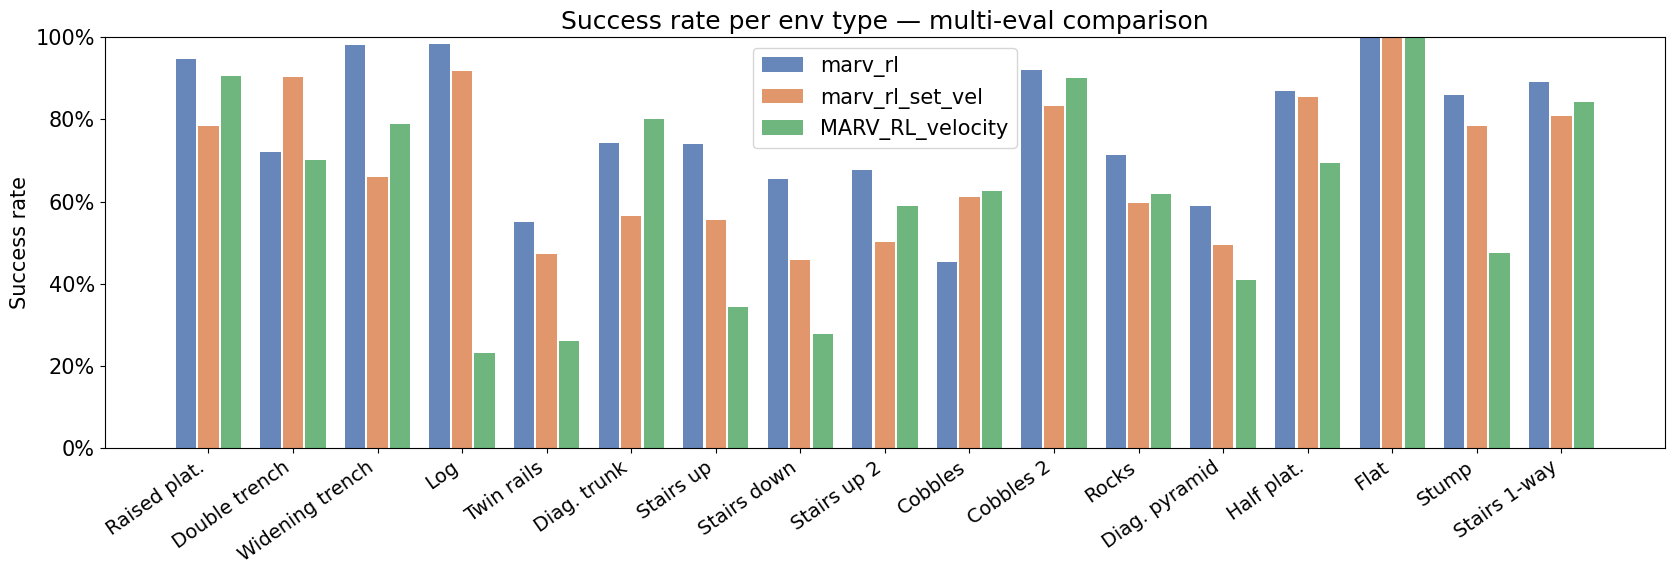

In [31]:
for ti, eids in terrain_groups(per_env_df):
    if len(eids) < 2:
        print(f"[info] {ti.name}: only one eval — nothing to compare "
              "(add more dirs to EVAL_DIRS, or more runs on this terrain).")
        continue

    sub_all = per_env_df[per_env_df.eval_id.isin(eids)]
    env_order = sorted(sub_all["env_type_idx"].unique())
    x = np.arange(len(env_order))
    n_evals = len(eids)
    width = 0.8 / n_evals

    fig, ax = plt.subplots(figsize=(max(12, len(env_order)), 6))
    for ei, eid in enumerate(eids):
        lbl = label_of(eid)
        sub = sub_all[sub_all.eval_id == eid].groupby("env_type_idx")["success_rate"].mean()
        vals = [sub.get(idx, np.nan) for idx in env_order]
        offset = (ei - n_evals / 2 + 0.5) * width
        ax.bar(x + offset, vals, width=width * 0.9,
               color=LABEL_COLOR[lbl], alpha=0.85, label=lbl)

    ax.set_xticks(x)
    ax.set_xticklabels([ti.short_of(i) for i in env_order], rotation=35, ha="right")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(fig_title(ti, "Success rate per env type — multi-eval comparison"))
    ax.set_ylabel("Success rate")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Difference heatmap (2 evals on this terrain only)
    if n_evals == 2:
        sr0 = sub_all[sub_all.eval_id == eids[0]].groupby("env_type_idx")["success_rate"].mean()
        sr1 = sub_all[sub_all.eval_id == eids[1]].groupby("env_type_idx")["success_rate"].mean()
        diff = np.array([sr1.get(i, np.nan) - sr0.get(i, np.nan) for i in env_order])
        lbl0, lbl1 = label_of(eids[0]), label_of(eids[1])

        fig, ax = plt.subplots(figsize=(max(12, len(env_order)), 4))
        im = ax.imshow([diff], aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1)
        ax.set_xticks(range(len(env_order)))
        ax.set_xticklabels([ti.short_of(i) for i in env_order], rotation=35, ha="right")
        ax.set_yticks([])
        for j, v in enumerate(diff):
            if not np.isnan(v):
                ax.text(j, 0, f"{v:+.1%}", ha="center", va="center", fontsize=13)
        ax.set_title(fig_title(ti, f"Δ success rate  ({lbl1} − {lbl0})"))
        plt.colorbar(im, ax=ax, fraction=0.05)
        plt.tight_layout()
        plt.show()

## 13  Policy vs. Random comparison

In [32]:
# Needs at least one trained-policy eval and one random eval (policy column == "random")
# on the same terrain.
for ti, eids in terrain_groups(per_env_df):
    sub_all = per_env_df[per_env_df.eval_id.isin(eids)]
    policy_evals = sub_all[sub_all["policy"] != "random"]["eval_id"].unique().tolist()
    random_evals = sub_all[sub_all["policy"] == "random"]["eval_id"].unique().tolist()
    print(f"{ti.name}: policy={policy_evals}  random={random_evals}")
    if not policy_evals or not random_evals:
        print(f"  [skip] {ti.name} needs at least one trained-policy eval and one random eval.")
        continue

    env_order = sorted(sub_all["env_type_idx"].unique())
    x = np.arange(len(env_order))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(12, len(env_order)), 5))
    for eids_grp, color, label, offset in [
        (policy_evals, PALETTE[0], "Trained policy", -width / 2),
        (random_evals, PALETTE[1], "Random",          width / 2),
    ]:
        sub = sub_all[sub_all.eval_id.isin(eids_grp)].groupby("env_type_idx")["success_rate"].mean()
        vals = [sub.get(idx, np.nan) for idx in env_order]
        ax.bar(x + offset, vals, width=width * 0.9, color=color, alpha=0.85, label=label)

    ax.set_xticks(x)
    ax.set_xticklabels([ti.short_of(i) for i in env_order], rotation=35, ha="right")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(fig_title(ti, "Policy vs. Random — success rate per env type"))
    ax.legend()
    plt.tight_layout()
    plt.show()

custom_mixed: policy=['MARV_RL_velocity', 'marv_rl', 'marv_rl_set_vel']  random=[]
  [skip] custom_mixed needs at least one trained-policy eval and one random eval.
